IMPORT PACKAGES

In [817]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import fdrcorrection
import matplotlib_venn
from venny4py.venny4py import *
from scipy import stats
import math
from matplotlib.lines import Line2D
from matplotlib.text import Text
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler
import lightgbm as lgb
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib
import random
import unicodeit
from matplotlib.colors import LinearSegmentedColormap
import umap
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.stats import shapiro

DEFINE FUNCTION

In [818]:
def histogram_entropy(data, bins=500):
    # Create histogram
    hist, bin_edges = np.histogram(data, bins=bins, density=True)

    # Normalize histogram to represent a probability density function
    hist = hist / hist.sum()
    
    # Remove zero entries to avoid log(0)
    hist = hist[hist > 0]
    
    # Calculate entropy
    entropy = -np.sum(hist * np.log(hist))
    
    return entropy

In [819]:
#Hàm wilcoxon mới
def STATS_binary(df_1,df_2,col_start,name_1,name_2,groups_PADJ=[]):
    # import pandas as pd
    # import numpy as np
    # from statsmodels.stats.multitest import fdrcorrection
    # from scipy import stats
    # import math
    Mean_1,Mean_2,Median_1,Median_2,Feature,P_value,AUC,Log2FC, Log2FC_Median=[],[],[],[],[],[],[],[],[]
    SD_1,SD_2,CVpct_1,CVpct_2=[],[],[],[]
    Entropy_1,Entropy_2=[],[]
    for i in range(col_start,df_1.shape[1]):
        #Mean
        m1=np.mean(list(df_1.iloc[:,i]))
        m2=np.mean(list(df_2.iloc[:,i]))
        Mean_1+=[m1]
        Mean_2+=[m2]
        #Median
        me1=np.median(list(df_1.iloc[:,i]))
        me2=np.median(list(df_2.iloc[:,i]))
        Median_1+=[me1]
        Median_2+=[me2]
        #P-value
        P_value+=[stats.ranksums(df_1.iloc[:,i],df_2.iloc[:,i])[1]]
        #Log2FC
        if m1 !=0 and m2 !=0:
            Log2FC+=[math.log2(abs(m2/m1))]
        else:
            Log2FC+=[0]

        if me1 !=0 and me2 !=0:
            Log2FC_Median+=[math.log2(abs(me2/me1))]
        else:
            Log2FC_Median+=[0]
        #Features
        Feature+=[df_1.columns[i]]
        #AUC
        AUC+=[metrics.roc_auc_score([0]*len(df_1)+[1]*len(df_2), list(df_1.iloc[:,i])+list(df_2.iloc[:,i]))]
        #SD and CV%
        sd1=np.std(list(df_1.iloc[:,i]))
        sd2=np.std(list(df_2.iloc[:,i]))
        SD_1+=[sd1]
        SD_2+=[sd2]
        if m1 != 0:
            CVpct_1+=[sd1/m1*100]
        else: 
            CVpct_1+=[np.nan]
        if m2 != 0:
            CVpct_2+=[sd2/m2*100]
        else: 
            CVpct_2+=[np.nan]
        #Entropy
        Entropy_1+=[histogram_entropy(data=list(df_1.iloc[:,i]),bins=int(len(df_1)/2))]
        Entropy_2+=[histogram_entropy(data=list(df_2.iloc[:,i]),bins=int(len(df_2)/2))]
    else:
        result=pd.DataFrame({'FEATURES':Feature,
                             'Mean of '+name_1:Mean_1,
                             'Mean of '+name_2:Mean_2,
                             'Median of '+name_1:Median_1,
                             'Median of '+name_2:Median_2,
                             'SD of '+name_1:SD_1,
                             'SD of '+name_2:SD_2,
                             'CV% of '+name_1:CVpct_1,
                             'CV% of '+name_2:CVpct_2,
                             'Entropy of '+name_1:Entropy_1,
                             'Entropy of '+name_2:Entropy_2, 
                             'Log2FC of '+name_1+' vs '+name_2:Log2FC,
                             'Log2FC Median of '+name_1+' vs '+name_2:Log2FC_Median,
                             'P of '+name_1+' vs '+name_2:P_value})
        #Adjust p-value
        PADJ=[]
        for g in groups_PADJ:
            filtered_result=result[result['FEATURES'].str.startswith(g)]
            if len(filtered_result)>0:
                PADJ+=list(fdrcorrection(filtered_result['P of '+name_1+' vs '+name_2])[1])
            else:
                PADJ+=[] 
        result['PADJ of '+name_1+' vs '+name_2]=PADJ
        result['Round_Mean of '+name_1]=result.apply(lambda row: round(row['Mean of '+name_1],2),axis=1)
        result['Round_Mean of '+name_2]=result.apply(lambda row: round(row['Mean of '+name_2],2),axis=1)
        result['-log10(p-value) of '+name_1+' vs '+name_2]=result.apply(lambda row: -math.log10(row['PADJ of '+name_1+' vs '+name_2]),axis=1)
        result['Distance of '+name_1+' vs '+name_2]=result.apply(lambda row: row['Mean of '+name_2]-row['Mean of '+name_1],axis=1)
        result['AUC of '+name_1+' vs '+name_2]=AUC
        result['AUCADJ of '+name_1+' vs '+name_2]=result.apply(lambda row: row['AUC of '+name_1+' vs '+name_2] if row['Log2FC of '+name_1+' vs '+name_2]>=0 else 1-row['AUC of '+name_1+' vs '+name_2],axis=1)
    return result
def STATS_features(df,pair,groups_PADJ=[],col_start=5):
    # import pandas as pd
    Cancer=df[df['Type']!='Healthy']
    Major=df[(df["Type"]=='Breast')|(df["Type"]=='Gastric')|(df["Type"]=='Colorectal')|(df["Type"]=='Liver')|(df["Type"]=='Lung')]
    Rare=df[(df["Type"]!='Breast')&(df["Type"]!='Gastric')&(df["Type"]!='Colorectal')&(df["Type"]!='Liver')&(df["Type"]!='Lung')]#|(df["Type"]=='Biliary tract')|(df["Type"]=='Kidney')|(df["Type"]=='Laryngeal'))]
    Healthy=df[df['Type']=='Healthy']
    Breast=df[df["Type"]=='Breast']
    Cervical=df[df["Type"]=='Cervical']
    Colorectal=df[df["Type"]=='Colorectal']
    Endometrial=df[df["Type"]=='Endometrial']
    Esophageal=df[df["Type"]=='Esophageal']
    Gastric=df[df["Type"]=='Gastric']
    Head_and_neck=df[df["Type"]=='Head and neck']
    Liver=df[df["Type"]=='Liver']
    Lung=df[df["Type"]=='Lung']
    Ovarian=df[df["Type"]=='Ovarian']
    Pancreatic=df[df["Type"]=='Pancreatic']
    Biliary_tract=df[df["Type"]=='Biliary tract']
    Laryngeal=df[df["Type"]=='Laryngeal']

    Group={
            'Cancer':Cancer,
            'Major':Major,
            'Rare':Rare,
            'Healthy':Healthy,
            'Breast':Breast,
            'Cervical':Cervical,
            'Colorectal':Colorectal,
            'Endometrial':Endometrial,
            'Esophageal':Esophageal,
            'Gastric':Gastric,
            'Head and neck':Head_and_neck,
            'Liver':Liver,
            'Lung':Lung,
            'Ovarian':Ovarian,
            'Pancreatic':Pancreatic,
            'Biliary tract':Biliary_tract,
            'Laryngeal':Laryngeal
            }
    result=pd.DataFrame()
    for p in pair:
        name_1=p.split(' vs ')[0]
        name_2=p.split(' vs ')[1]
        stats_bi=STATS_binary(df_1=Group[name_1],df_2=Group[name_2],col_start=col_start,name_1=name_1,name_2=name_2,groups_PADJ=groups_PADJ)
        result=pd.concat([result,stats_bi],axis=1)
    else:
        result = result.loc[:,~result.columns.duplicated()].copy()
    return result

def introundup(a):
    import math
    b=math.ceil(a)
    c=len(str(b))
    d=pow(10,c-1)
    e=a/d
    f=math.ceil(e)
    g=f*d
    return g
def features_include(features,lst_fea,fsm,f_group):
    df=pd.DataFrame({'FEATURES':list(lst_fea)})
    Number=[]
    for f in features:
        Number+=[len(df[df['FEATURES'].str.startswith(f)])]
    fea_include=pd.DataFrame({'FEATURES':features,fsm+' | '+f_group:Number})
    return fea_include

Volcanofea

In [820]:
def volcanofea(f,pair=['Lung vs Heathy'],alpha=0.05,show_region=False):
    data=stats_fea[f]
    data.index=data.FEATURES
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        col_log='Log2FC of '+p
        col_PADJ='-log10(p-value) of '+p
        cols=[]
        for r in data['FEATURES']:
            if data.loc[r,'PADJ of '+p] >=alpha:
                cols+=['gray']
            elif data.loc[r,'PADJ of '+p] < alpha:
                if data.loc[r,col_log] >= 0:
                    cols+=['r']
                else:
                    cols+=['b']
        plt.figure(figsize=(6,6))
        x=data[col_log]
        y=data[col_PADJ]
        sb.scatterplot(x=x,y=y,c=cols,linewidth=0.5,edgecolor='black')
        plt.axvline(x=0, color='gray', label='axvline - full height',ls='--')
        left, right = plt.xlim()
        plt.axhline(y=-math.log10(alpha), color='green', label='axhline - full height',ls='--')
        plt.xlabel(u'log\u2082(fold change of means '+p.split(' vs ')[1]+'/'+ p.split(' vs ')[0]+')')
        plt.ylabel(unicodeit.replace('-log_1_0(adjusted p-value)'))
        plt.title('Volcano plot - '+f+' - '+p)
        # plt.yticks(np.arange(0,8,1))
        # plt.xticks(np.arange(-0.1,0.4,0.1))
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.2))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        lst_name_show=list(data[((data[col_log]<=-0.1)|(data[col_log]>=0.015))]['FEATURES'])
        if show_region:
            region_name = list(data['FEATURES'])
            for i, txt in enumerate(region_name):
                if txt in lst_name_show:
                    plt.text(x[i],y[i],txt,fontsize=8,color='red')

AUCplotfea

In [821]:
def AUCplotfea(f,pair=['Lung vs Healthy'],alpha=0.05): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES','PADJ of '+p,'Log2FC of '+p,'AUCADJ of '+p]]
        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL' or f=='TMD':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        plt.figure(figsize=(10,5))
        sb.scatterplot(data=df,x=x,y=list(df['AUCADJ of '+p]),c=cols)
        plt.yticks(np.arange(0.3,1.05,0.05))
        plt.xticks([])
        plt.xlabel('Regions')
        plt.ylabel('AUC')
        plt.title('AUC of '+f+' features - '+p)
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.5))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

Variability

In [822]:
def Varplotfea(f,pair=['Lung vs Healthy'],sig=False,alpha=0.05,VAR='AUC',ytick=[0,110,10],fea_compare='TMD',show_region=False,region_to_show=[]): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES',
                        'PADJ of '+p,
                        'Log2FC of '+p,
                        'AUCADJ of '+p,
                        # 'CV% of Healthy',
                        # 'Entropy of Healthy',
                        'CV% of '+p.split(' vs ')[0],
                        'CV% of '+p.split(' vs ')[1],
                        'Entropy of '+p.split(' vs ')[0],
                        'Entropy of '+p.split(' vs ')[1],                        
                        ]]
        df.fillna(0,inplace=True)
        mean_=[np.mean(list(df[VAR+' of '+p.split(' vs ')[0]])),np.mean(list(df[VAR+' of '+p.split(' vs ')[1]]))]
        if sig:
            df=df[df['PADJ of '+p]<alpha]          

        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        elif f in ['TM_CNA','TM_flen','TM_EM']:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        elif f =='GWMD' or f=='CNA':
            x=[i for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[1] for i in list(df['FEATURES'])]

        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        
        if VAR == 'AUC':
            plt.figure(figsize=(10,5))
            sb.scatterplot(data=df,x=x,y=list(df[VAR+'ADJ of '+p]),c=cols)
            plt.yticks(np.arange(0.3,1.05,0.05))
            plt.xticks([])
            plt.xlabel('Regions (features)')
            plt.ylabel(VAR)
            plt.title(VAR+' of '+f+' features - '+p)
        else:
            for i in [0,1]:
                plt.figure(figsize=(10,5))
                y=list(df[VAR+' of '+p.split(' vs ')[i]])
                sb.scatterplot(data=df,x=x,y=y,c=cols,markers='.')
                # plt.axhline(y=np.mean(list(df[VAR+' of Healthy'])), color='magenta', label='axvline - full height',ls='--')
                # plt.axhline(y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), color='red', label='axvline - full height',ls='--')
                plt.axhline(y=mean_[i], color='black', label='axvline - full height',ls='--')
                # plt.text(x=len(x)*1.06, y=np.mean(list(df[VAR+' of Healthy']))+ytick[2]/10, s='Average in Healthy', fontsize=12,color='magenta')
                # plt.text(x=len(x)*1.06, y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), s='Average in '+fea_compare+' of '+p.split(' vs ')[i], fontsize=12,color='red')
                plt.text(x=len(x)*1.06, y=mean_[i]-ytick[2]/3, s='Average in '+p.split(' vs ')[i], fontsize=12)
                plt.yticks(np.arange(ytick[0],ytick[1],ytick[2]))
                plt.xticks([])
                plt.xlabel('Regions (features)')
                plt.ylabel(VAR)
                plt.title(VAR+' of '+f+' features - '+p.split(' vs ')[i])

                se_cols=pd.Series(cols)
                count=se_cols.value_counts()
                lst=[]
                for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
                    lst+=[i+' ('+str(count.get(j, 0))+')']
                plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                if show_region:
                    region_name = list(df['FEATURES'])
                    for i, txt in enumerate(region_name):
                        if txt in region_to_show:
                            plt.text(x[i],y[i],txt,fontsize=8,color='red')

        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

PCAsigfea

In [823]:
def PCAsigfea(DATA,SAMPLES,stats_fea,dict_cols,p='A vs B',f='TMD',
              sig=True,alpha=0.05,show_ID=False,IDs=[],
              plot_pct_explain=False,top_pc=2,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='PCA.png'
              ):
    
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2


    pca=PCA(random_state=0)
    pca.fit(data.iloc[:,col_start:])
    pca_data=pca.transform(data.iloc[:,col_start:])

    # pca_data=pca.transform(scaled_data)

    per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)
    labels=['PC'+str(x) for x in range(1,len(per_var)+1)]

    if plot_pct_explain ==True:
        if top_pc > data.shape[1]-col_start:
            top_pc = data.shape[1]-col_start
        ax1=plt.figure(figsize=(5,5))
        plt.bar(x=range(1,len(per_var[0:top_pc])+1),height=per_var[0:top_pc],tick_label=labels[0:top_pc])
        plt.ylabel('Percentage of Explained Variance')   
        plt.xlabel('Principal Component')
        if sig:
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:        
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+f,pad=20)
        plt.yticks(np.arange(0,110,top_pc))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        if save:
            plt.savefig(figname[0:len(figname)-4]+'_top10.png',dpi=600,bbox_inches='tight')
    

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(pca_data[:,0][i], pca_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('PCA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('PCA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | '+p+' | '+f,pad=20)
    
    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


LDAsigfea

In [824]:
def LDAsigfea(DATA,SAMPLES,stats_fea,
            dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
            p='Nongastric vs Gastric',
            f='EM',
            sig=False,
            alpha=0.05,
            show_ID=False,
            IDs=[],
            yticks=[0,5,1],
            xticks=[0,5,1],
            save=False,
            figname='LDA.png'):
              
    
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Label0=[]
    Type0=[]
    for s in data0['SampleID']:
        Type0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
        Label0+=[list(sample_list0[sample_list0['SampleID']==s]['Label'])[0]]
    data0.insert(loc=1,column='Type',value=Type0)
    data0.insert(loc=1,column='Label',value=Label0)


    data1=DATA[f][vector1]
    Label1=[]
    Type1=[]
    for s in data1['SampleID']:
        Type1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
        Label1+=[list(sample_list1[sample_list1['SampleID']==s]['Label'])[0]]
    data1.insert(loc=1,column='Type',value=Type1)
    data1.insert(loc=1,column='Label',value=Label1)

    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)

    col_start=3


    lda=LDA()
    X=data.iloc[:,col_start:]
    y=list(data.iloc[:,2])
    lda_data=lda.fit_transform(X, y)

    # pca_data=pca.transform(scaled_data)
    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=lda_data[:,0],y=lda_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(lda_data[:,0][i], lda_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('LD 1')
    plt.ylabel('LD 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('LDA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('LDA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('LDA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('LDA | '+p+' | '+f,pad=20)

    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


In [825]:
def LDAbinary(pairs=['Healthy vs Lung'],features=['TMD'],sig=True,alpha=0.05,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='LDA.png'
              ):
    for p in pairs:
        LDA_data=pd.DataFrame()
        for f in features:
            if sig:
                sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
                df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
            else:
                df=fea[f]

            if df.shape[1]<=col_start:
                df=fea[f]
                
            Healthy=df[df['Class']==0]
            Lung=df[df['Class']==1]


            Group={'Lung':Lung,
                    'Healthy':Healthy,
                    }
            
            data_pair0=Group[p.split(' vs ')[0]]
            data_pair0.insert(loc=1,column='Group',value=0)
            data_pair1=Group[p.split(' vs ')[1]]
            data_pair1.insert(loc=1,column='Group',value=1)
            data_pair=pd.concat([data_pair0,data_pair1],axis=0)
            data_pair.reset_index(drop=True,inplace=True)
            # data_pair

            X=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
            y=data_pair['Group']

            lda=LDA()
            X_train = lda.fit_transform(X, y)

            lst=[]
            for i in range(len(X_train)):
                lst+=[X_train[i,0]]
            LDA_data[f]=list(lst)
            # else:
            LDA_data['Class']=y
            cols=[]
            for t in data_pair['Class']:
                if t == 0: cols+=['b']
                elif t == 1: cols+=['r']
                #Plot LDA
        plt.figure(figsize=(len(features)*3,5))
        ax=sb.swarmplot(data=LDA_data.melt(id_vars='Class'),x='variable',y='value',c=cols)
        custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=7),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7)
                            ]
        plt.legend(custom_lines,['Healthy','Lung'],loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
        plt.xticks(ticks=[0],labels=['']
                   )
        plt.xlabel('')
        plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
        plt.ylabel('LD1')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title('LDA | '+p+' | '+f,pad=20)
        if save:
            plt.savefig(figname,dpi=600,bbox_inches='tight')


UMAPfea

In [826]:
def UMAPfea(
        DATA, SAMPLES,stats_fea,dict_cols,
        f='EM',p='Healthy vs Lung',
        sig=False,alpha=0.05,show_ID=False,IDs=[],
        yticks=[0,5,1],
        xticks=[0,5,1],
        n_neighbors=3,n_components=2,
        save=False,figname='UMAP.png'
            ):
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2
    umap_model = umap.UMAP(n_neighbors=n_neighbors,n_components=n_components, random_state=0)
    X_umap = umap_model.fit_transform(data.iloc[:,col_start:])

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_umap[:, 0],y=X_umap[:, 1],c=cols)
    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(X_umap[:,0][i],X_umap[:,1][i], label, fontsize=12, ha='right')
    plt.title('UMAP | '+p+' | '+f+' | n_neighbors='+str(n_neighbors),pad=20)
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # plt.yticks(np.arange(0,9,1))
    # plt.xticks(np.arange(-6,18,2))

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))

    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')

TSMEfea

In [827]:
def TSNEfea(
    DATA, SAMPLES,stats_fea,dict_cols,f='EM',
    p='Healthy vs Lung',
    sig=True,alpha=0.05,show_ID=False,IDs=[],
    yticks=[0,5,1],
    xticks=[0,5,1],
    perplexity=30,
    save=False,
    figname='TSNE.png'):

    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2

    tsne = TSNE(perplexity=perplexity,n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(data.iloc[:,col_start:])

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)


    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_tsne[:, 0],y=X_tsne[:, 1],c=cols)
    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(X_tsne[:,0][i], X_tsne[:,1][i], label, fontsize=12, ha='right')

    plt.title('t-SNE | '+p+' | '+f+' | perplexity='+str(perplexity),pad=20)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


FEATURES

In [828]:
#features=['EM','FLEN','NFP','CNA','SCNA','RATIOSL','RATIOST','CLE']
features=['EM','FLEN','NFP','CNA','SCNA','RATIOSL','RATIOST']

In [829]:
# STOP

DATA

In [830]:
EM=pd.read_csv(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\EM.csv')
cols=[]
for c in list(EM.columns[1:]):
    cols+=['EM_'+c]
EM.columns=['SampleID']+cols
#-----------------------------------------------------------------------
FLEN=pd.read_csv(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\FLEN.csv')
cols=[]
for c in list(FLEN.columns[1:]):
    cols+=['FLEN_'+c]
FLEN.columns=['SampleID']+cols
#-----------------------------------------------------------------------
NFP=pd.read_csv(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\NFP.csv')
cols=[]
for c in list(NFP.columns[1:]):
    cols+=['NFP_'+c]
NFP.columns=['SampleID']+cols
#-----------------------------------------------------------------------
CNA=pd.read_csv(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\CNA.csv')
cols=[]
for c in list(CNA.columns[1:]):
    cols+=['CNA_'+c]
CNA.columns=['SampleID']+cols
#-----------------------------------------------------------------------
SCNA=pd.read_csv(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\SCNA.csv')
cols=[]
for c in list(SCNA.columns[1:]):
    cols+=['SCNA_'+c]
SCNA.columns=['SampleID']+cols
#-----------------------------------------------------------------------
RATIOSL=pd.read_csv(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\RATIOSL.csv')
cols=[]
for c in list(RATIOSL.columns[1:]):
    cols+=['RATIOSL_'+c]
RATIOSL.columns=['SampleID']+cols
#-----------------------------------------------------------------------
RATIOST=pd.read_csv(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\RATIOST.csv')
cols=[]
for c in list(RATIOST.columns[1:]):
    cols+=['RATIOST_'+c]
RATIOST.columns=['SampleID']+cols
#-----------------------------------------------------------------------
#CLE=pd.read_csv('D:\VoDacHo\Database\Data\cleave_profile\CLE.csv')
#cols=[]
#for c in list(CLE.columns[1:]):
#    cols+=['CLE_'+c]
#CLE.columns=['SampleID']+cols

In [831]:
DATA={
    'EM':EM,
    'FLEN':FLEN,
    'NFP':NFP,
    'CNA':CNA,
    'SCNA':SCNA,
    'RATIOSL':RATIOSL,
    'RATIOST':RATIOST,
    #'CLE':CLE
}

DANH SÁCH MẪU

In [832]:
exp_id='Gastric2'

In [833]:
metadata=pd.read_excel(r'C:\Users\XN\du-an-dung-chung\HNG_3_20250824\Metadata_3.xlsx',sheet_name='QC')
metadata

,STT,Type,SampleID,Labcode,Label,Ngày thu mẫu,Ngày nhận mẫu,Mã nghiên cứu,Bệnh viện,Họ và tên,...,Giai đoạn trước mổ,Giai đoạn sau mổ,Chẩn đoán lâm sàng/Triệu chứng đầu tiên vào viện,Stage,Giai đoạn theo TNM,Kích thước khối u,CEA\n(ng/mL),CA72-4\n(U/mL),CA19-9\n(U/mL),Notes
0,1,Gastric,HNGK003,HNGK003,1,25/10/2024,28/10/2024,P2,DHYHN,TƯỞNG THỊ LUÂN,...,T3N0,T2N1M0,NaN,IIA,II,NaN,NaN,NaN,NaN,NaN
1,2,Gastric,HNGK004,HNGK004,1,28/10/2024,30/10/2024,P3,DHYHN,LÊ THỊ NGÂN,...,K hang môn vị,T1N0M0,NaN,IA,I,NaN,NaN,NaN,NaN,NaN
2,3,Gastric,HNGK005,HNGK005,1,31/10/2024,02/11/2024,P4,DHYHN,PHẠM QUANG SỸ,...,T2N0M0,T2N0M0,NaN,IB,I,NaN,NaN,NaN,NaN,NaN
3,4,Gastric,HNGK007,HNGK007,1,04/11/2024,05/11/2024,P6,DHYHN,BÙI VĂN ĐƯỢC,...,T3N0M0,T3N0M0,NaN,IIA,II,NaN,NaN,NaN,NaN,có cặn trắng
4,5,Gastric,HNGK008,HNGK008,1,05/11/2024,07/11/2024,P7,DHYHN,PHẠM THẾ ANH,...,T2N0M0,T1aN0M0,NaN,IA,I,NaN,NaN,NaN,NaN,có cặn trắng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,259,Healthy,HNGH131,HNGH131,0,13/08/2025,14/08/2025,C129,DHYHN,Nguyễn Văn Lễ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259,260,Healthy,HNGH132,HNGH132,0,19/08/2025,20/08/2025,C130,DHYHN,Nguyễn Hữu Dũng,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
260,261,Healthy,HNGH133,HNGH133,0,21/08/2025,23/08/2025,C132,DHYHN,Nguyễn Đức Thắng,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TM50
261,262,Healthy,HNGH134,HNGH134,0,21/08/2025,23/08/2025,C133,DHYHN,Vi Văn Nam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [834]:
# liver=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Liver')]
# liver_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Liver_benign')]
# lung=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Lung')]
# lung_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Lung_benign')]
# colorectal=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Colorectal')]
# colorectal_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Colorectal_benign')]
# gastric=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Gastric')]
gastric=metadata[(metadata['Type']=='Gastric')]
# gastric_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Gastric_benign')]
# pancreatic=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Pancreatic')]
# esophageal=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Esophageal')]
# head_and_neck=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Head_and_neck')]
# breast=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Breast')]
# breast_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Breast_benign')]
# ovarian=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Ovarian')]
# ovarian_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Ovarian_benign')]
# endometrial=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Endometrial')]
# healthy=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Healthy')]
healthy=metadata[(metadata['Type']=='Healthy')]
# Nongastric=pd.concat([healthy,gastric_benign],axis=0)

In [835]:
SAMPLES={
    # 'Healthy':healthy[healthy['Have data CLE']=='Yes'],
     'Healthy':healthy,
    # 'Colorectal':colorectal,
    # 'Liver':liver,
    # 'Lung':lung,
    # 'Gastric':gastric[gastric['Have data CLE']=='Yes'],
    'Gastric':gastric,
    # 'Pancreatic':pancreatic,
    # 'Esophageal':esophageal,
    # 'Head_and_neck':head_and_neck,
    # 'Breast':breast,
    # 'Ovarian':ovarian,
    # 'Endometrial':endometrial,
    # 'Colorectal_benign':colorectal_benign,
    # 'Liver_benign':liver_benign,
    # 'Lung_benign':lung_benign,
    #'Gastric_benign':gastric_benign[gastric_benign['Have data CLE']=='Yes'],
    # 'Breast_benign':breast_benign,
    # 'Ovarian_benign':ovarian_benign,
    # 'Nongastric':Nongastric[Nongastric['Have data CLE']=='Yes']
}

In [836]:
# sample_list_all=pd.concat([healthy,gastric_benign,gastric],axis=0)
sample_list_all=pd.concat([healthy,gastric],axis=0)
sample_list_all

,STT,Type,SampleID,Labcode,Label,Ngày thu mẫu,Ngày nhận mẫu,Mã nghiên cứu,Bệnh viện,Họ và tên,...,Giai đoạn trước mổ,Giai đoạn sau mổ,Chẩn đoán lâm sàng/Triệu chứng đầu tiên vào viện,Stage,Giai đoạn theo TNM,Kích thước khối u,CEA\n(ng/mL),CA72-4\n(U/mL),CA19-9\n(U/mL),Notes
140,141,Healthy,HNGH001,HNGH001,0,06/03/2025,07/03/2025,C1,DHYHN,ĐÀO TRỌNG BẢY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,142,Healthy,HNGH002,HNGH002,0,06/03/2025,07/03/2025,C3,DHYHN,BÙI THỊ LOAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mẹ bị K gan --> Loại
142,143,Healthy,HNGH003,HNGH003,0,06/03/2025,07/03/2025,C2,DHYHN,NGUYỄN NHƯ MINH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,144,Healthy,HNGH004,HNGH004,0,11/03/2025,12/03/2025,C4,DHYHN,ĐOÀN VĂN HUYỀN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cần trả kq
144,145,Healthy,HNGH005,HNGH005,0,11/03/2025,13/03/2025,C5,DHYHN,LÊ THỊ HẢI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,136,Gastric,HNGK183,HNGK183,1,23/07/2025,24/07/2025,P176,BV K,ĐỖ THỊ LOAN,...,T3N0M0,pT4aN2M0,NaN,IIIA,III,NaN,NaN,NaN,NaN,NaN
136,137,Gastric,HNGK184,HNGK184,1,24/07/2025,25/07/2025,P177,BV K,TRẦN THỊ CÚC,...,T2N0M0,TisN0M0,NaN,ZERO,I,NaN,NaN,NaN,NaN,NaN
137,138,Gastric,HNGK185,HNGK185,1,28/07/2025,30/07/2025,P178,BV K,DƯƠNG THỊ SIM,...,T2N0M0,T3N0M0,NaN,IIA,II,NaN,NaN,NaN,NaN,TM 50
138,139,Gastric,HNGK186,HNGK186,1,01/08/2025,02/08/2025,P179,BV K,PHÙNG VĂN HIỆP,...,T2N0M0,pT1bN0M0,NaN,IA,I,NaN,NaN,NaN,NaN,NaN


In [837]:
#plt.figure(figsize=(5,9))
#plt.figure(figsize=(5,9))
#sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
#           #palette=['b','g','r'],
#           palette=['b','r'],
#           #order=['Healthy','Gastric_benign','Gastric'],
#           order=['Healthy','Gastric'],
#           fill=False,linewidth=2,
#           flierprops=dict(marker='.',markersize=3),
#           showfliers=True,legend=False,
#           dodge=False,width=0.8,gap=0.1)

#sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
#             #palette=['b','g','r'],size=4,marker='.',linewidth=0,legend=False,
#             palette=['b','r'],size=4,marker='.',linewidth=0,legend=False,
#             dodge=False,
#             #order=['Healthy','Gastric_benign','Gastric'])
#             order=['Healthy','Gastric'])

#plt.ylim(1.5,1.5)
#plt.yticks(np.arange(0,1.5,0.5))
#plt.ylabel('cfDNA conc (ng/ul)')
#plt.xlabel('Type')
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.axhline(y=2.5,ls='--',color='gray')


In [838]:
#import seaborn as sb
#import matplotlib.pyplot as plt
#import numpy as np
#from scipy.stats import kruskal

# Tính p-value theo nhóm 'Type'
#groups = [group['cfDNA conc'].dropna().tolist()
#          for _, group in sample_list_all.groupby('Type')]
#stat, p_value = kruskal(*groups)

#plt.figure(figsize=(5, 9))

# Boxplot: không fill, có viền màu
#sb.boxplot(data=sample_list_all,
#           y='cfDNA conc',
#           x='Type',
#           palette=['b', 'r'],
#           order=['Healthy', 'Gastric'],
#           fill=False,
#           linewidth=2,
#           flierprops=dict(marker='.', markersize=3),
#           showfliers=True,
#           dodge=False,
#           width=0.8,
#           gap=0.1)

# Scatter dot
#sb.stripplot(data=sample_list_all,
#             y='cfDNA conc',
#             x='Type',
#             palette=['b', 'r'],
#             size=4,
#             marker='.',
#             linewidth=0,
#             legend=False,
#             dodge=False,
#             order=['Healthy', 'Gastric'])

# Thiết lập trục tung
#plt.ylim(0, 1.2)
#plt.yticks(np.arange(0, 1.21, 0.2))

# Nhãn trục
#plt.ylabel('cfDNA conc (ng/ul)')
#plt.xlabel('Type')

# Viền quanh toàn bộ biểu đồ
#ax = plt.gca()
#for spine in ax.spines.values():
#    spine.set_visible(True)
#    spine.set_linewidth(1.5)

# Thêm giá trị p
#plt.text(0.5, 1.15, f'p = {p_value:.4f}', ha='center', fontsize=12)

#plt.tight_layout()
#plt.show()




In [839]:
#import numpy as np
#import pandas as pd
#from scipy import stats

# Tách 2 nhóm
#healthy = sample_list_all[sample_list_all['Type'] == 'Healthy']['cfDNA conc']
#gastric = sample_list_all[sample_list_all['Type'] == 'Gastric']['cfDNA conc']

# Tính trung vị
#median_healthy = np.median(healthy)
#median_gastric = np.median(gastric)

# Hàm tính khoảng tin cậy 95% bằng bootstrap
#def bootstrap_ci(data, n_bootstrap=1000, ci=95):
#    boot_medians = []
#    for _ in range(n_bootstrap):
#        sample = np.random.choice(data, size=len(data), replace=True)
#        boot_medians.append(np.median(sample))
#    lower = np.percentile(boot_medians, (100 - ci) / 2)
#    upper = np.percentile(boot_medians, 100 - (100 - ci) / 2)
#    return lower, upper

# Tính khoảng tin cậy
#ci_healthy = bootstrap_ci(healthy)
#ci_gastric = bootstrap_ci(gastric)

# Kiểm định Mann-Whitney U
#u_stat, p_value = stats.mannwhitneyu(healthy, gastric, alternative='two-sided')

# In kết quả
#print(f"Healthy Median: {median_healthy:.3f} ng/ul, 95% CI: {ci_healthy}")
#print(f"Gastric Median: {median_gastric:.3f} ng/ul, 95% CI: {ci_gastric}")
#print(f"Mann-Whitney U Test: U = {u_stat}, p = {p_value:.4f}")



In [840]:
#import pandas as pd
#import matplotlib.pyplot as plt
#from scipy.stats import kruskal
#import numpy as np

# Đọc dữ liệu
#df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_2\Metadata_2.xlsx", sheet_name="QC")

# Chuẩn hóa tên cột
#df.columns = df.columns.str.strip().str.lower()
#df = df.rename(columns={
#    'loại mẫu': 'type',
#    'giai đoạn theo tnm': 'tnm',
#    'cfdna conc (ng/ml)': 'cfdna conc'
#})

# Lọc dữ liệu gastric và loại bỏ NA
#gastric_df = df[df['type'].str.lower() == 'gastric'].dropna(subset=['tnm', 'cfdna conc'])

# Đảm bảo thứ tự TNM
#order = ['I', 'II', 'III']
#gastric_df['tnm'] = pd.Categorical(gastric_df['tnm'], categories=order, ordered=True)

# Kiểm định Kruskal-Wallis
#grouped = gastric_df.groupby("tnm")["cfdna conc"].apply(list)
#stat, p_value = kruskal(*grouped)

# Thiết lập màu và vị trí
#colors = plt.cm.tab10.colors[:len(order)]
#positions = range(1, len(order) + 1)

# Vẽ boxplot
#plt.figure(figsize=(10, 6))
#box = plt.boxplot(
#    [grouped[cat] for cat in order],
#    positions=positions,
#    patch_artist=True,
#    widths=0.6
#)

# Chỉnh boxplot: trong suốt, có viền màu
#for patch, color in zip(box['boxes'], colors):
#    patch.set_facecolor('none')           # Trong suốt
#    patch.set_edgecolor(color)
#    patch.set_linewidth(2)

# Scatter dot nhỏ hơn
#for i, cat in enumerate(order):
#    y = grouped[cat]
#    x = np.random.normal(loc=positions[i], scale=0.05, size=len(y))
#    plt.scatter(x, y, color=colors[i], alpha=0.6, edgecolors='k', s=25)

# Thiết lập biểu đồ
#plt.xticks(positions, order, rotation=45, ha='right')
#plt.xlabel("TNM Stage")
#plt.ylabel("cfDNA conc (ng/ul)")
#plt.title(f"cfDNA by TNM Stage (p = {p_value:.4f})")
#plt.grid(False)
#plt.tight_layout()
#plt.show()



THỐNG KÊ ĐẶC ĐIỂM ĐỐI TƯỢNG NC

In [841]:
import pandas as pd
from scipy.stats import chi2_contingency

# Đọc dữ liệu
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_3_20250824\Metadata_3.xlsx"  # Đường dẫn tới file của bạn
data = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_3_20250824\Metadata_3.xlsx", sheet_name='QC')

# Lọc dữ liệu nhóm Gastric và Healthy
filtered_data = data[data['Type'].isin(['Gastric', 'Healthy'])]

# Chuẩn hóa giá trị giới tính
filtered_data['Giới tính'] = filtered_data['Giới tính'].str.strip()

# Đếm số lượng nam/nữ theo nhóm
gender_counts = pd.crosstab(filtered_data['Type'], filtered_data['Giới tính'])
gender_percentages = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100

# Định dạng bảng kết quả
new_columns = pd.MultiIndex.from_tuples([
    ("Gender", "Gastric", "N"),
    ("Gender", "Gastric", "%"),
    ("Gender", "Healthy", "N"),
    ("Gender", "Healthy", "%")
])

formatted_table = pd.DataFrame([
    [gender_counts.loc["Gastric", "NAM"], gender_percentages.loc["Gastric", "NAM"],
     gender_counts.loc["Healthy", "NAM"], gender_percentages.loc["Healthy", "NAM"]],
    [gender_counts.loc["Gastric", "NỮ"], gender_percentages.loc["Gastric", "NỮ"],
     gender_counts.loc["Healthy", "NỮ"], gender_percentages.loc["Healthy", "NỮ"]]
],
    index=["Male", "Female"],
    columns=new_columns
)

print("Bảng kết quả giới tính theo nhóm:")
print(formatted_table)

# Thực hiện kiểm định Chi-squared
chi2_stat, p_value, dof, expected = chi2_contingency(gender_counts)

# Diễn giải kết quả
interpretation = "Có sự khác biệt có ý nghĩa thống kê (p < 0.05)" if p_value < 0.05 else "Không có sự khác biệt có ý nghĩa thống kê (p ≥ 0.05)"

# Hiển thị kết quả kiểm định
print("\nKết quả kiểm định Chi-squared:")
print(f"Chi-squared statistic: {chi2_stat}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)
print("Phiên giải:", interpretation)



Bảng kết quả giới tính theo nhóm:
        Gender                              
       Gastric            Healthy           
             N          %       N          %
Male        81  57.857143      51  41.463415
Female      59  42.142857      57  46.341463

Kết quả kiểm định Chi-squared:
Chi-squared statistic: 20.84088205738752
p-value: 0.00011359768740127866
Degrees of freedom: 3
Expected frequencies:
 [[70.2661597   7.45247148 61.74904943  0.53231939]
 [61.7338403   6.54752852 54.25095057  0.46768061]]
Phiên giải: Có sự khác biệt có ý nghĩa thống kê (p < 0.05)


In [842]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, chi2_contingency

# 📥 Đọc dữ liệu
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_3_20250824\Metadata_3.xlsx"
data = pd.read_excel(file_path, sheet_name='QC')

# 🎯 Lọc dữ liệu chỉ lấy nhóm Gastric và Healthy
filtered_data = data[data['Type'].isin(['Gastric', 'Healthy'])].copy()
filtered_data['Giới tính'] = filtered_data['Giới tính'].str.strip()  # Chuẩn hóa giới tính

# =========================================
# 📌 1. TÍNH TUỔI + KIỂM ĐỊNH SỰ KHÁC BIỆT
print("📊 Thống kê tuổi theo nhóm:")
for group in ['Gastric', 'Healthy']:
    ages = filtered_data[filtered_data['Type'] == group]['Tuổi'].dropna()
    print(f"\n{group}:")
    print(f"  Số lượng: {len(ages)}")
    print(f"  Mean: {ages.mean():.2f}")
    print(f"  Min: {ages.min()}, Max: {ages.max()}")
    print(f"  Median: {ages.median():.2f}")

# 🧪 Kiểm định phân phối tuổi (Shapiro-Wilk)
gastric_age = filtered_data[filtered_data['Type'] == 'Gastric']['Tuổi'].dropna()
healthy_age = filtered_data[filtered_data['Type'] == 'Healthy']['Tuổi'].dropna()

_, p_gastric = shapiro(gastric_age)
_, p_healthy = shapiro(healthy_age)
print("\n🔍 Kiểm định phân phối tuổi (Shapiro-Wilk):")
print(f"  Gastric: p = {p_gastric:.4f} {'✅ Bình thường' if p_gastric >= 0.05 else '❌ Không bình thường'}")
print(f"  Healthy: p = {p_healthy:.4f} {'✅ Bình thường' if p_healthy >= 0.05 else '❌ Không bình thường'}")

# 🧪 Kiểm định sự khác biệt tuổi giữa 2 nhóm
if p_gastric >= 0.05 and p_healthy >= 0.05:
    stat, p_age = ttest_ind(gastric_age, healthy_age)
    method = "T-test"
else:
    stat, p_age = mannwhitneyu(gastric_age, healthy_age, alternative='two-sided')
    method = "Mann-Whitney U test"

print(f"\n🧪 {method} giữa Gastric và Healthy:")
print(f"  Statistic: {stat:.4f}, p-value: {p_age:.4g}")
if p_age < 0.05:
    print("  ✅ Kết luận: Có sự khác biệt tuổi giữa Gastric và Healthy.")
else:
    print("  ❌ Kết luận: Không có sự khác biệt tuổi giữa Gastric và Healthy.")



📊 Thống kê tuổi theo nhóm:

Gastric:
  Số lượng: 140
  Mean: 61.98
  Min: 32, Max: 86
  Median: 63.00

Healthy:
  Số lượng: 123
  Mean: 59.19
  Min: 28, Max: 85
  Median: 60.00

🔍 Kiểm định phân phối tuổi (Shapiro-Wilk):
  Gastric: p = 0.0728 ✅ Bình thường
  Healthy: p = 0.9659 ✅ Bình thường

🧪 T-test giữa Gastric và Healthy:
  Statistic: 2.1195, p-value: 0.03499
  ✅ Kết luận: Có sự khác biệt tuổi giữa Gastric và Healthy.


In [843]:
#plt.figure(figsize=(5,9))
#sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
#           palette=['b','g','r'],
#           order=['Healthy','Gastric_benign','Gastric'],
#           fill=False,linewidth=2,
#           flierprops=dict(marker='.',markersize=3),
#           showfliers=True,legend=False,
#           dodge=False,width=0.8,gap=0.1)
#
#sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
#             palette=['b','g','r'],size=4,marker='.',linewidth=0,legend=False,
#             dodge=False,
#             order=['Healthy','Gastric_benign','Gastric'])
#plt.ylim(2,9)
#plt.yticks(np.arange(0,10,0.5))
#plt.ylabel('ng/ul')
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.axhline(y=0.5,ls='--',color='gray')

THỐNG KÊ

In [844]:
FEATURES=[]
Group=[]
P_value=[]
for f in features:
    p_value=[]
    vector=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list_all['SampleID']):
            vector+=[True]
        else:
            vector+=[False]
    data=DATA[f][vector]
    for c in data.columns[1:]:
        FEATURES+=[c]
        Group+=[f]
        p_value+=[shapiro(data[c])[1]]
    P_value+=list(fdrcorrection(p_value)[1])
df_norm=pd.DataFrame({
    'FEATURES':FEATURES,
    'Group':Group,
    'p_value':P_value
})
df_norm

c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,FEATURES,Group,p_value
0,EM_AAAA,EM,1.119052e-03
1,EM_AAAC,EM,4.257454e-01
2,EM_AAAG,EM,2.024065e-11
3,EM_AAAT,EM,1.745548e-04
4,EM_AACA,EM,8.942195e-04
...,...,...,...
10783,RATIOST_Y:10000001-11000000,RATIOST,6.398317e-01
10784,RATIOST_Y:13000001-14000000,RATIOST,2.007392e-03
10785,RATIOST_Y:58000001-59000000,RATIOST,4.599485e-01
10786,RATIOST_Y:59000001-59373566,RATIOST,2.220880e-01


In [845]:
df_norm['Group'].value_counts()

Group
RATIOST    2874
RATIOSL    2872
SCNA       1942
CNA        1942
NFP         601
FLEN        301
EM          256
Name: count, dtype: int64

In [846]:
df_norm[df_norm['p_value']>0.05]['Group'].value_counts()

Group
SCNA       1326
CNA        1017
NFP         429
RATIOST     224
EM           39
FLEN         28
RATIOSL       4
Name: count, dtype: int64

In [847]:
df_norm[df_norm['p_value']>0.05]

,FEATURES,Group,p_value
1,EM_AAAC,EM,0.425745
11,EM_AAGT,EM,0.072676
77,EM_CATC,EM,0.915544
87,EM_CCCT,EM,0.482067
92,EM_CCTA,EM,0.186690
...,...,...,...
10709,RATIOST_X:3000001-4000000,RATIOST,0.071200
10783,RATIOST_Y:10000001-11000000,RATIOST,0.639832
10785,RATIOST_Y:58000001-59000000,RATIOST,0.459948
10786,RATIOST_Y:59000001-59373566,RATIOST,0.222088


In [848]:
# list_columns_vlookup=[exp_id+'Cohort','Label','Class','Type','Age','Gender']
list_columns_vlookup=['Label','Class','Type','Age','Gender']

In [849]:
# col_start=len(list_columns_vlookup)+1
# col_start
col_start=len(list_columns_vlookup)+1
col_start

6

In [850]:
#PAIR=[
#    'Healthy vs Gastric',
#    'Gastric_benign vs Gastric',
#    'Nongastric vs Gastric'
#]
PAIR=[
    'Healthy vs Gastric',
]


In [851]:
# stats_fea={}
# for f in features:
#     result=pd.DataFrame()
#     for p in PAIR:
#         name_1=p.split(' vs ')[0]
#         name_2=p.split(' vs ')[1]

#         vector1=[]
#         for s in list(DATA[f]['SampleID']):
#             if s in list(SAMPLES[name_1]['SampleID']):
#                 vector1+=[True]
#             else:
#                 vector1+=[False]
#         df_1=DATA[f][vector1]

#         vector2=[]
#         for s in list(DATA[f]['SampleID']):
#             if s in list(SAMPLES[name_2]['SampleID']):
#                 vector2+=[True]
#             else:
#                 vector2+=[False]
#         df_2=DATA[f][vector2]

#         stats_bi=STATS_binary(df_1=df_1,df_2=df_2,col_start=1,name_1=name_1,name_2=name_2,groups_PADJ=[f])
#         result=pd.concat([result,stats_bi],axis=1)
#     else:
#         result = result.loc[:,~result.columns.duplicated()].copy()
#         stats_fea[f]=result

In [852]:
# !!!! Chỉ chạy 1 lần xong khóa code lại 
#with pd.ExcelWriter(exp_id + '_STATS.xlsx') as writer:
#   for f in features:
#        if f not in ['CONCAT', 'CONCAT21', 'CONCAT21TM']:
#            stats_fea[f].to_excel(writer, sheet_name=f, index=False)


In [853]:
stats_fea={}
for f in features:
    stats_fea[f]=pd.read_excel(exp_id+'_STATS.xlsx',sheet_name=f)
    
    

In [854]:
stats_fea['EM']

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,EM_AAAA,0.009190,0.009217,0.009256,0.009265,0.000595,0.000610,6.479154,6.621842,3.620333,...,0.004084,0.001357,0.682236,0.867418,0.01,0.01,0.061772,0.000026,0.514943,0.514943
1,EM_AAAC,0.003757,0.003722,0.003755,0.003727,0.000145,0.000141,3.847839,3.778671,3.331385,...,-0.013630,-0.010867,0.047949,0.238956,0.00,0.00,0.621683,-0.000035,0.427813,0.572187
2,EM_AAAG,0.005746,0.005767,0.005770,0.005818,0.000244,0.000309,4.245413,5.363801,3.619222,...,0.005325,0.011985,0.305851,0.626409,0.01,0.01,0.203142,0.000021,0.537373,0.537373
3,EM_AAAT,0.005868,0.005869,0.005876,0.005887,0.000392,0.000342,6.682112,5.832850,3.572531,...,0.000327,0.002709,0.883700,0.962305,0.01,0.01,0.016687,0.000001,0.494661,0.494661
4,EM_AACA,0.004183,0.004161,0.004190,0.004157,0.000148,0.000172,3.542426,4.128214,3.447807,...,-0.007683,-0.011467,0.085769,0.322895,0.00,0.00,0.490939,-0.000022,0.437291,0.562709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,EM_TTGT,0.001530,0.001562,0.001526,0.001553,0.000163,0.000169,10.670011,10.816997,3.734758,...,0.030439,0.024687,0.249292,0.589841,0.00,0.00,0.229265,0.000033,0.542048,0.542048
252,EM_TTTA,0.003214,0.003253,0.003282,0.003274,0.000420,0.000390,13.072181,12.002284,3.651466,...,0.017382,-0.003687,0.724624,0.875017,0.00,0.00,0.057983,0.000039,0.512858,0.512858
253,EM_TTTC,0.002354,0.002390,0.002407,0.002391,0.000234,0.000249,9.946275,10.411083,3.594138,...,0.021910,-0.009904,0.655765,0.860902,0.00,0.00,0.065046,0.000036,0.516270,0.516270
254,EM_TTTG,0.001860,0.001906,0.001876,0.001900,0.000212,0.000217,11.387235,11.405776,3.687578,...,0.035609,0.018544,0.259390,0.592891,0.00,0.00,0.227025,0.000046,0.541164,0.541164


In [855]:
Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[(df['PADJ of '+p]<0.05)&(df['Log2FC Median of '+p]<0)])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,EM,FLEN,NFP,CNA,SCNA,RATIOSL,RATIOST
0,Healthy vs Gastric,0,57,0,0,0,0,0


In [856]:
Thong_ke_stats_split.to_clipboard(index=False)

In [857]:
Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[(df['PADJ of '+p]<0.05)&(df['Log2FC Median of '+p]>=0)])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,EM,FLEN,NFP,CNA,SCNA,RATIOSL,RATIOST
0,Healthy vs Gastric,1,46,0,0,0,2852,2852


In [858]:
Thong_ke_stats_split.to_clipboard(index=False)

EM ven

In [859]:
#f='EM'
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

In [860]:
#f='EM'
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

EM heatmap log2FC

In [861]:
p=PAIR[0]
# p=PAIR[1]
# p=PAIR[2]

In [862]:
sample_list=pd.concat([SAMPLES[p.split(' vs ')[0]],SAMPLES[p.split(' vs ')[1]]],axis=0)
sample_list

,STT,Type,SampleID,Labcode,Label,Ngày thu mẫu,Ngày nhận mẫu,Mã nghiên cứu,Bệnh viện,Họ và tên,...,Giai đoạn trước mổ,Giai đoạn sau mổ,Chẩn đoán lâm sàng/Triệu chứng đầu tiên vào viện,Stage,Giai đoạn theo TNM,Kích thước khối u,CEA\n(ng/mL),CA72-4\n(U/mL),CA19-9\n(U/mL),Notes
140,141,Healthy,HNGH001,HNGH001,0,06/03/2025,07/03/2025,C1,DHYHN,ĐÀO TRỌNG BẢY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,142,Healthy,HNGH002,HNGH002,0,06/03/2025,07/03/2025,C3,DHYHN,BÙI THỊ LOAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mẹ bị K gan --> Loại
142,143,Healthy,HNGH003,HNGH003,0,06/03/2025,07/03/2025,C2,DHYHN,NGUYỄN NHƯ MINH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,144,Healthy,HNGH004,HNGH004,0,11/03/2025,12/03/2025,C4,DHYHN,ĐOÀN VĂN HUYỀN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cần trả kq
144,145,Healthy,HNGH005,HNGH005,0,11/03/2025,13/03/2025,C5,DHYHN,LÊ THỊ HẢI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,136,Gastric,HNGK183,HNGK183,1,23/07/2025,24/07/2025,P176,BV K,ĐỖ THỊ LOAN,...,T3N0M0,pT4aN2M0,NaN,IIIA,III,NaN,NaN,NaN,NaN,NaN
136,137,Gastric,HNGK184,HNGK184,1,24/07/2025,25/07/2025,P177,BV K,TRẦN THỊ CÚC,...,T2N0M0,TisN0M0,NaN,ZERO,I,NaN,NaN,NaN,NaN,NaN
137,138,Gastric,HNGK185,HNGK185,1,28/07/2025,30/07/2025,P178,BV K,DƯƠNG THỊ SIM,...,T2N0M0,T3N0M0,NaN,IIA,II,NaN,NaN,NaN,NaN,TM 50
138,139,Gastric,HNGK186,HNGK186,1,01/08/2025,02/08/2025,P179,BV K,PHÙNG VĂN HIỆP,...,T2N0M0,pT1bN0M0,NaN,IA,I,NaN,NaN,NaN,NaN,NaN


In [863]:
result=pd.DataFrame(stats_fea['EM'])
result['nu_start']=result.apply(lambda row: row['FEATURES'][-4],axis=1)
result.index=result.apply(lambda row: row['FEATURES'][-4:],axis=1)
result.sort_values(by=['nu_start','Mean of '+p.split(' vs ')[0],],ascending=True)
result

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric,nu_start
AAAA,EM_AAAA,0.009190,0.009217,0.009256,0.009265,0.000595,0.000610,6.479154,6.621842,3.620333,...,0.001357,0.682236,0.867418,0.01,0.01,0.061772,0.000026,0.514943,0.514943,A
AAAC,EM_AAAC,0.003757,0.003722,0.003755,0.003727,0.000145,0.000141,3.847839,3.778671,3.331385,...,-0.010867,0.047949,0.238956,0.00,0.00,0.621683,-0.000035,0.427813,0.572187,A
AAAG,EM_AAAG,0.005746,0.005767,0.005770,0.005818,0.000244,0.000309,4.245413,5.363801,3.619222,...,0.011985,0.305851,0.626409,0.01,0.01,0.203142,0.000021,0.537373,0.537373,A
AAAT,EM_AAAT,0.005868,0.005869,0.005876,0.005887,0.000392,0.000342,6.682112,5.832850,3.572531,...,0.002709,0.883700,0.962305,0.01,0.01,0.016687,0.000001,0.494661,0.494661,A
AACA,EM_AACA,0.004183,0.004161,0.004190,0.004157,0.000148,0.000172,3.542426,4.128214,3.447807,...,-0.011467,0.085769,0.322895,0.00,0.00,0.490939,-0.000022,0.437291,0.562709,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGT,EM_TTGT,0.001530,0.001562,0.001526,0.001553,0.000163,0.000169,10.670011,10.816997,3.734758,...,0.024687,0.249292,0.589841,0.00,0.00,0.229265,0.000033,0.542048,0.542048,T
TTTA,EM_TTTA,0.003214,0.003253,0.003282,0.003274,0.000420,0.000390,13.072181,12.002284,3.651466,...,-0.003687,0.724624,0.875017,0.00,0.00,0.057983,0.000039,0.512858,0.512858,T
TTTC,EM_TTTC,0.002354,0.002390,0.002407,0.002391,0.000234,0.000249,9.946275,10.411083,3.594138,...,-0.009904,0.655765,0.860902,0.00,0.00,0.065046,0.000036,0.516270,0.516270,T
TTTG,EM_TTTG,0.001860,0.001906,0.001876,0.001900,0.000212,0.000217,11.387235,11.405776,3.687578,...,0.018544,0.259390,0.592891,0.00,0.00,0.227025,0.000046,0.541164,0.541164,T


In [864]:
result['Log2FC_+-']=result.apply(lambda r: 0 if r['Log2FC Median of '+p]<0 else 1,axis=1)
result['ABS Log2FC Median of '+p]=result.apply(lambda r: abs(r['Log2FC Median of '+p]),axis=1)
result['Sig']=result.apply(lambda r: 0 if r['PADJ of '+p] <=0.05 else 1,axis=1)
nu_start_order=[]
for nu_start in result['nu_start']:
    if nu_start == 'A':
        nu_start_order+=[0]
    elif nu_start == 'T':
        nu_start_order+=[1]
    elif nu_start == 'G':
        nu_start_order+=[2]
    elif nu_start == 'C':
        nu_start_order+=[3]    
result['nu_start_order']=nu_start_order
result

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric,nu_start,Log2FC_+-,ABS Log2FC Median of Healthy vs Gastric,Sig,nu_start_order
AAAA,EM_AAAA,0.009190,0.009217,0.009256,0.009265,0.000595,0.000610,6.479154,6.621842,3.620333,...,0.01,0.061772,0.000026,0.514943,0.514943,A,1,0.001357,1,0
AAAC,EM_AAAC,0.003757,0.003722,0.003755,0.003727,0.000145,0.000141,3.847839,3.778671,3.331385,...,0.00,0.621683,-0.000035,0.427813,0.572187,A,0,0.010867,1,0
AAAG,EM_AAAG,0.005746,0.005767,0.005770,0.005818,0.000244,0.000309,4.245413,5.363801,3.619222,...,0.01,0.203142,0.000021,0.537373,0.537373,A,1,0.011985,1,0
AAAT,EM_AAAT,0.005868,0.005869,0.005876,0.005887,0.000392,0.000342,6.682112,5.832850,3.572531,...,0.01,0.016687,0.000001,0.494661,0.494661,A,1,0.002709,1,0
AACA,EM_AACA,0.004183,0.004161,0.004190,0.004157,0.000148,0.000172,3.542426,4.128214,3.447807,...,0.00,0.490939,-0.000022,0.437291,0.562709,A,0,0.011467,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGT,EM_TTGT,0.001530,0.001562,0.001526,0.001553,0.000163,0.000169,10.670011,10.816997,3.734758,...,0.00,0.229265,0.000033,0.542048,0.542048,T,1,0.024687,1,1
TTTA,EM_TTTA,0.003214,0.003253,0.003282,0.003274,0.000420,0.000390,13.072181,12.002284,3.651466,...,0.00,0.057983,0.000039,0.512858,0.512858,T,0,0.003687,1,1
TTTC,EM_TTTC,0.002354,0.002390,0.002407,0.002391,0.000234,0.000249,9.946275,10.411083,3.594138,...,0.00,0.065046,0.000036,0.516270,0.516270,T,0,0.009904,1,1
TTTG,EM_TTTG,0.001860,0.001906,0.001876,0.001900,0.000212,0.000217,11.387235,11.405776,3.687578,...,0.00,0.227025,0.000046,0.541164,0.541164,T,1,0.018544,1,1


C:\Users\XN\AppData\Local\Temp\ipykernel_2928\2400276928.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users\XN\AppData\Local\Temp\ipykernel_2928\2400276928.py:87: UserWarning: 
The palette list has fewer values (1) than needed (64) and will cycle, which may produce an uninterpretable plot.
  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users\XN\AppData\Local\Temp\ipykernel_2928\2400276928.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users\XN

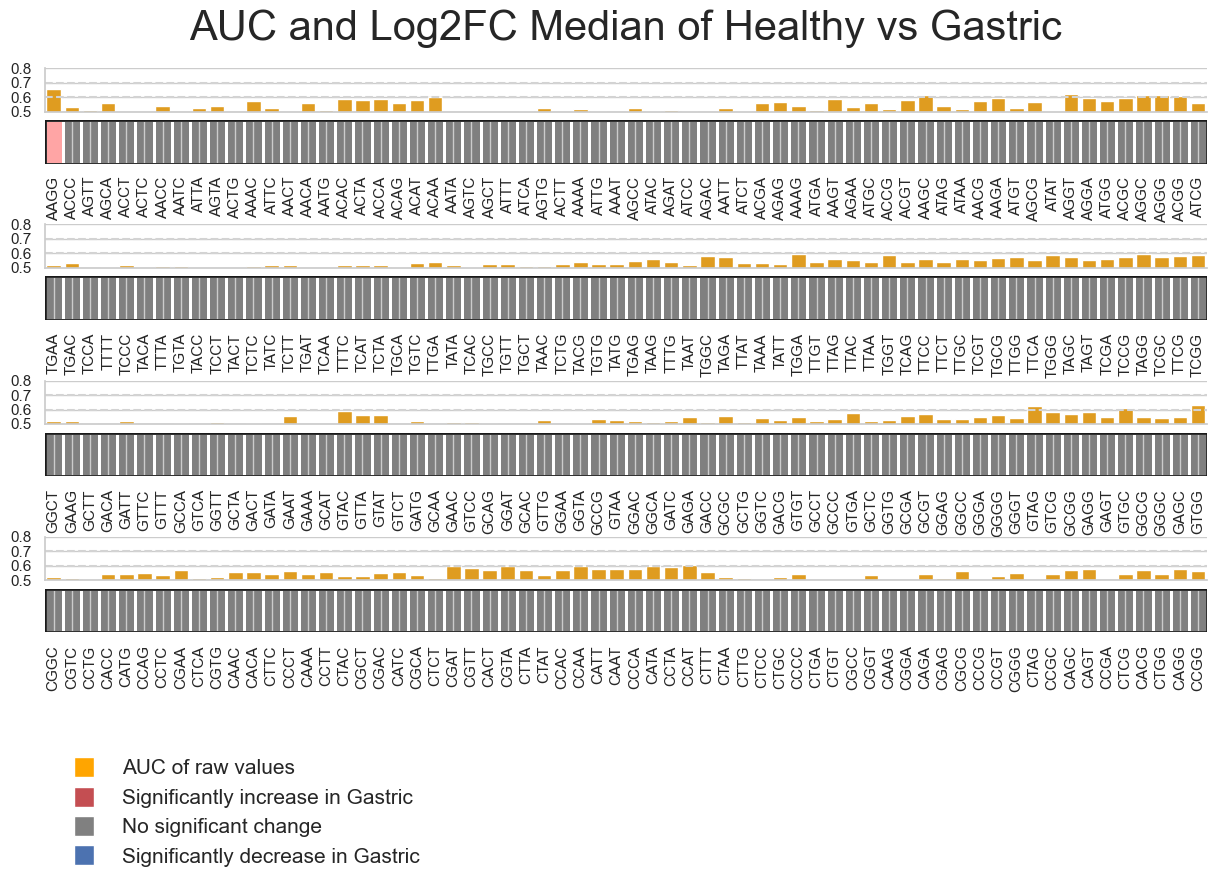

In [865]:
# data=result.sort_values(by=['nu_start','PlusMinus_Log2FC_'+p.split('-')[0]+'_'+p.split('-')[1],'ABS_Log2FC_'+p.split('-')[0]+'_'+p.split('-')[1]],ascending=True)
data=result.sort_values(by=['nu_start_order','Sig','Log2FC_+-','ABS Log2FC Median of '+p,],ascending=True)
# data=result
# cols=['Mean_F_Healthy','Mean_M_Healthy']
lst_PDAJ=list(data[data['PADJ of '+p.split(' vs ')[0]+' vs '+p.split(' vs ')[1]]<0.05]['FEATURES'])
set1=lst_PDAJ
# for n in [1,2,3,4,5,6,7,8]:
fig, axs = plt.subplots(12, 1, figsize=(15, 8))

for n in [1,2,3,4]:
        # A=data[cols][32*(n-1):32*n].T
        # A=data[['Mean of '+p.split(' vs ')[0],'Mean of '+p.split(' vs ')[1]]][64*(n-1):64*n].T
        # cmap = matplotlib.colormaps["Greens"]
        #         # Set the under color to white
        #         # cmap.set_under("yellow")
        #         # # Set the voer color to white
        #         # cmap.set_over("black")
        # # Set the background color
        # plt.figure(figsize=(15,1))
        # g = sb.heatmap(A,
        #                 # vmin=0,
        #                 # vmax=0.0125,
        #                 cmap=cmap,
        #                 # mask=mask_array,
        #                 yticklabels=True,
        #                 linewidths=2)
        # Set color of masked region
        # g.set_facecolor('gray')
        # if n==1: plt.title(col)
        # plt.title(col)

        lst_out=[]
        for i in list(np.arange(64*(n-1),64*n)):
                # if data['FEATURES'].iloc[i] not in lst_PDAJ:
                if data['FEATURES'].iloc[i] not in set(stats_fea['EM'][stats_fea['EM']['PADJ of '+p]<0.05]['FEATURES']):
                        lst_out+=[i-64*(n-1)]


        col = 'Log2FC Median of '+p.split(' vs ')[0]+' vs '+p.split(' vs ')[1]




        B = data[[col]][64*(n-1):64*n].T
        B.index=[B.columns[0][0]]
        mask_array = np.zeros((1, 64), dtype=bool)
        mask_array[:, lst_out] = True
        cmap = matplotlib.colormaps["seismic"]
        # Set the under color to white
        # cmap.set_under("yellow")
        # # Set the voer color to white
        # cmap.set_over("black")
        # Set the background color
        # plt.figure(figsize=(15,0.7))
        # cbar=True if n==1 else False
        g = sb.heatmap(B,
                        # vmin=-max([abs(min(data[col])),abs(max(data[col]))]),
                        # vmax=max([abs(min(data[col])),abs(max(data[col]))]),
                        vmin=-0.16,
                        vmax=0.16,
                        cmap=cmap,
                        mask=mask_array,
                        yticklabels=False,
                        linewidths=2,
                        # linecolor='black',
                        cbar=False,
                        # cbar_kws={'shrink': 1, 'fraction': 0.5, 'pad': 0.03},
                        # ax=axs[n-1])
                        # ax=axs[2*n-1])
                        ax=axs[(n-1)*3+1])
        # Set color of masked region
        g.set_facecolor('gray')
        # plt.title(col)ax.axhline(y=0, color='k',linewidth=10)
        g.axhline(y=0, color='k',linewidth=2)
        g.axhline(y=1, color='k',linewidth=2)
        g.axvline(x=0, color='k',linewidth=2)
        g.axvline(x=64, color='k',linewidth=2)
        for labe in g.get_xticklabels():
                text = 'EM_'+labe.get_text()
                #if text in overlap012:
                #        labe.set_color('magenta')
                #elif text in overlap01:
                #        labe.set_color('g')



        g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
                #       ax=axs[2*n-2],
                      ax=axs[(n-1)*3],
                      palette=['orange'])
        g1.axhline(y=0.6,ls='--',color='lightgray')
        g1.axhline(y=0.7,ls='--',color='lightgray')
        g1.spines['top'].set_visible(False)
        g1.spines['right'].set_visible(False)
        g1.tick_params(axis='x', labelrotation=90,labelbottom=False)
        g1.set_xlabel('')
        g1.set_ylabel('')
        g1.set_yticks([0.5,0.6,0.7,0.8])
        # sb.despine(left=True)
        g1.set_xlim(left=-0.5)
        g1.set_ylim([0.5,0.8])

        if n==1: g1.set_title('AUC and '+col,pad=20,fontsize=30)

        axs[(n-1)*3+2].axis('off')
plt.tight_layout()
custom_lines = [Line2D([0], [0],marker='s', color='w', markerfacecolor='orange', markersize=15),
        Line2D([0], [0],marker='s', color='w', markerfacecolor='r', markersize=15),
                Line2D([0], [0],marker='s', color='w', markerfacecolor='gray', markersize=15),
                    Line2D([0], [0],marker='s', color='w', markerfacecolor='b', markersize=15),
                    ]
plt.legend(custom_lines,['AUC of raw values','Significantly increase in '+p.split(' vs ')[1],'No significant change','Significantly decrease in '+p.split(' vs ')[1]],loc='upper left',fontsize=15, bbox_to_anchor=(0, -1.3),frameon=False)
# plt.savefig('.\Figure\EM.png', dpi=600, bbox_inches='tight')
plt.subplots_adjust(hspace=0.2)

EM top sig

In [866]:
#stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True).head(5)[['PADJ of '+PAIR[0],'PADJ of '+PAIR[1],'PADJ of '+PAIR[2]]]
stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True).head(5)[['PADJ of '+PAIR[0]]]

,PADJ of Healthy vs Gastric
0,0.391700
1,0.912524
2,0.132459
3,0.132187
4,0.138171


In [867]:
stats_fea['EM'].sort_values(by='Log2FC Median of '+p,ascending=False).reset_index(drop=True)

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,EM_TCGG,0.000100,0.000106,0.000099,0.000104,0.000019,0.000020,19.519227,19.116209,3.353716,...,0.093043,0.071544,0.012157,0.138171,0.00,0.00,0.859584,0.000007,0.591521,0.591521
1,EM_TTCG,0.000115,0.000121,0.000114,0.000118,0.000016,0.000022,13.687968,18.409228,3.595399,...,0.068846,0.051071,0.030008,0.210261,0.00,0.00,0.677241,0.000006,0.579200,0.579200
2,EM_ATCG,0.000159,0.000162,0.000155,0.000161,0.000016,0.000024,10.353066,14.574551,3.098135,...,0.031303,0.050842,0.091605,0.335012,0.00,0.00,0.474939,0.000003,0.561572,0.561572
3,EM_TCGC,0.000098,0.000102,0.000097,0.000101,0.000013,0.000014,13.180034,13.783215,3.418964,...,0.060135,0.050490,0.039064,0.227759,0.00,0.00,0.642524,0.000004,0.575314,0.575314
4,EM_ACGG,0.000166,0.000171,0.000165,0.000170,0.000013,0.000013,8.100623,7.757461,3.185416,...,0.038103,0.045603,0.003260,0.092738,0.00,0.00,1.032743,0.000004,0.607380,0.607380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,EM_CCTA,0.010486,0.010294,0.010461,0.010286,0.000508,0.000564,4.848485,5.476415,3.581528,...,-0.026580,-0.024241,0.012954,0.138171,0.01,0.01,0.859584,-0.000191,0.409301,0.590699
252,EM_CCAT,0.014637,0.014333,0.014592,0.014333,0.000687,0.000748,4.693148,5.220929,3.635513,...,-0.030358,-0.025847,0.005164,0.132187,0.01,0.01,0.878811,-0.000305,0.397928,0.602072
253,EM_ACAA,0.005249,0.005188,0.005268,0.005169,0.000237,0.000265,4.520855,5.104911,3.584896,...,-0.016724,-0.027300,0.006726,0.132459,0.01,0.01,0.877918,-0.000060,0.401087,0.598913
254,EM_AATA,0.002877,0.002880,0.002916,0.002861,0.000231,0.000217,8.043036,7.540704,3.444536,...,0.001598,-0.027816,0.798459,0.912524,0.00,0.00,0.039756,0.000003,0.490680,0.490680


In [868]:
EM_top=list(stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True)['FEATURES'][0:5])+list(stats_fea['EM'].sort_values(by='Log2FC Median of '+p,ascending=False).reset_index(drop=True)['FEATURES'][0:5])
EM_top

['EM_CTTT',
 'EM_AATA',
 'EM_ACAA',
 'EM_CCAT',
 'EM_CCTA',
 'EM_TCGG',
 'EM_TTCG',
 'EM_ATCG',
 'EM_TCGC',
 'EM_ACGG']

In [869]:
f='EM'
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list[sample_list['SampleID']==s]['Label'])[0]]
data.insert(loc=1,column='Label',value=labels)
data.sort_values(by='SampleID',inplace=True)
data.reset_index(drop=True,inplace=True)
EM_plot1=data[['Label']+EM_top[0:5]].melt(id_vars="Label")
EM_plot1['x']=EM_plot1.apply(lambda r: r['variable'][3:]+'_'+str(int(r['Label'])),axis=1)
EM_plot1.sort_values(by='x',inplace=True)
EM_plot1

C:\Users\XN\AppData\Local\Temp\ipykernel_2928\4088704475.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='SampleID',inplace=True)


,Label,variable,value,x
314,0,EM_AATA,0.003448,AATA_0
340,0,EM_AATA,0.002693,AATA_0
339,0,EM_AATA,0.002916,AATA_0
338,0,EM_AATA,0.002929,AATA_0
337,0,EM_AATA,0.002933,AATA_0
...,...,...,...,...
162,1,EM_CTTT,0.011500,CTTT_1
161,1,EM_CTTT,0.011983,CTTT_1
160,1,EM_CTTT,0.012655,CTTT_1
173,1,EM_CTTT,0.011088,CTTT_1


In [870]:
EM_plot2=data[['Label']+EM_top[5:10]].melt(id_vars="Label")
EM_plot2

,Label,variable,value
0,0,EM_TCGG,0.000079
1,0,EM_TCGG,0.000046
2,0,EM_TCGG,0.000063
3,0,EM_TCGG,0.000091
4,0,EM_TCGG,0.000089
...,...,...,...
1255,1,EM_ACGG,0.000189
1256,1,EM_ACGG,0.000170
1257,1,EM_ACGG,0.000176
1258,1,EM_ACGG,0.000158


Text(-1.1, -0.0065, '**  p-value < 0.05')

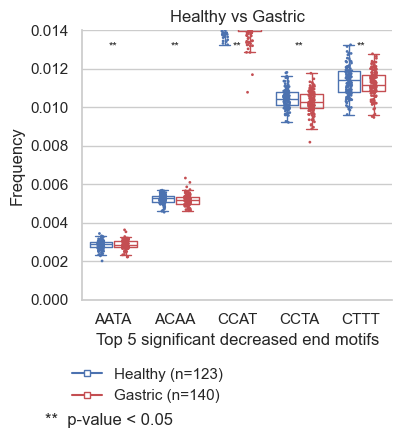

In [871]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot1,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot1,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
plt.yticks(np.arange(0,0.016,0.002))
plt.ylim(0,0.014)
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot1['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant decreased end motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p-value < 0.00001','Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.3, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.05, .1),loc='center right',frameon=False)
tys=[p.split(' vs ')[0]+' (n='+str(len(SAMPLES[p.split(' vs ')[0]]))+')',
     p.split(' vs ')[1]+' (n='+str(len(SAMPLES[p.split(' vs ')[1]]))+')']
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
plt.title(p)
plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')
# plt.text(x=4.7,y=0.007,s='**',fontsize=8)
# plt.savefig('.\Figure/EM_top5_1.png',dpi=600,bbox_inches='tight')

Text(-1.1, -0.0065, '**  p-value < 0.05')

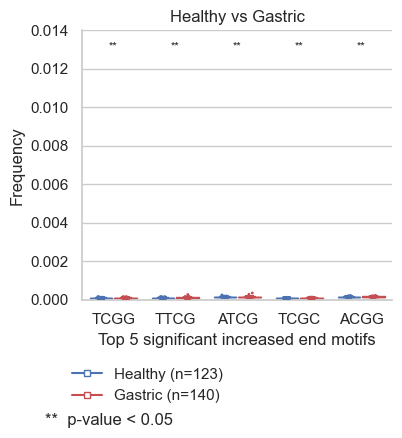

In [872]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,
             dodge=True
             )
plt.yticks(np.arange(0,0.016,0.002))
plt.ylim(0,0.014)
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant increased end motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
tys=[p.split(' vs ')[0]+' (n='+str(len(SAMPLES[p.split(' vs ')[0]]))+')',
     p.split(' vs ')[1]+' (n='+str(len(SAMPLES[p.split(' vs ')[1]]))+')']
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
plt.title(p)
plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')

Text(-1.1, -0.0065, '**  p-value < 0.05')

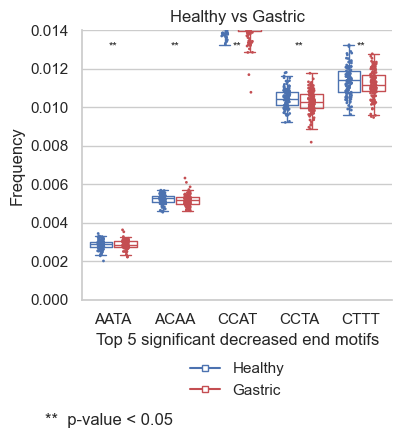

In [873]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sb
import numpy as np

plt.figure(figsize=(4, 3.5))

# Vẽ boxplot
sb.boxplot(data=EM_plot1, y='value', x='variable', hue='Label',
           palette=['b', 'r'], hue_order=[0, 1], fill=False, linewidth=1,
           flierprops=dict(marker='.', markersize=3),
           showfliers=False, legend=False,
           dodge=True, width=0.8, gap=0.1)

# Vẽ stripplot
sb.stripplot(data=EM_plot1, y='value', x='variable', hue='Label',
             palette=['b', 'r'], hue_order=[0, 1],
             marker='.', size=4, linewidth=0, legend=False,
             dodge=True)

plt.yticks(np.arange(0, 0.016, 0.002))
plt.ylim(0, 0.014)
plt.xticks(ticks=[0, 1, 2, 3, 4],
           labels=[em.split('_')[1] for em in list(EM_plot1['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant decreased end motifs')

# Xóa viền trục trên và phải
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Chú giải màu sắc – hạ thấp với khoảng cách ~0.5cm và bỏ n=...
custom_lines = [
    Line2D([0], [0], marker='s', color='b', markerfacecolor='w', markersize=5),
    Line2D([0], [0], marker='s', color='r', markerfacecolor='w', markersize=5),
]
plt.legend(custom_lines,
           ['Healthy', 'Gastric'],
           bbox_to_anchor=(0.5, -0.18),  # Hạ thấp legend ~0.5cm
           loc='upper center',
           ncol=1,
           frameon=False)

# Thêm chú thích dấu **
for x in range(5):
    plt.text(x=x, y=0.013, s='**', ha='center', fontsize=8)

# Tiêu đề và chú thích p-value
plt.title(p)
plt.text(x=-1.1, y=-0.0065, s='**  p-value < 0.05')



Text(-1.1, -0.0065, '**  p-value < 0.05')

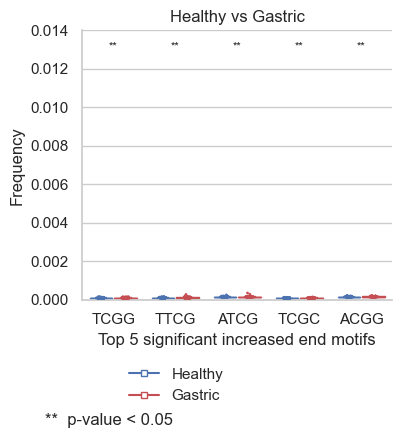

In [874]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,
             dodge=True
             )
plt.yticks(np.arange(0,0.016,0.002))
plt.ylim(0,0.014)
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant increased end motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
tys=[p.split(' vs ')[0],
     p.split(' vs ')[1]]
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
plt.title(p)
plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')

In [875]:
EM_plot2=data[['Label']+['EM_AAGG']].melt(id_vars="Label")
EM_plot2

,Label,variable,value
0,0,EM_AAGG,0.002261
1,0,EM_AAGG,0.002243
2,0,EM_AAGG,0.002242
3,0,EM_AAGG,0.002197
4,0,EM_AAGG,0.002310
...,...,...,...
247,1,EM_AAGG,0.002436
248,1,EM_AAGG,0.002257
249,1,EM_AAGG,0.002264
250,1,EM_AAGG,0.002238


Text(0.5, 1.0, 'Healthy vs Gastric')

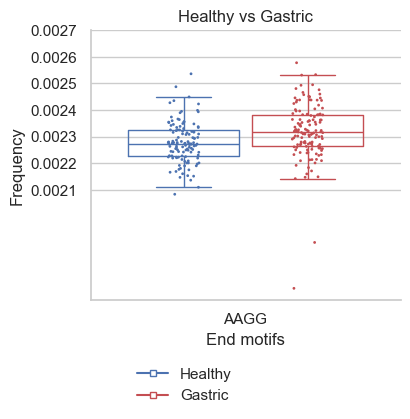

In [876]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,
             dodge=True
             )
plt.yticks(np.arange(0.0021,0.0027,0.0001))
# plt.ylim(0,0.014)
plt.xticks(ticks=[0,
               #    1,2,3,4
                  ],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Frequency')
# plt.xlabel('Top 5 significant increased end motifs')
plt.xlabel('End motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
tys=[p.split(' vs ')[0],
     p.split(' vs ')[1]]
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
# plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
plt.title(p)
# plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')

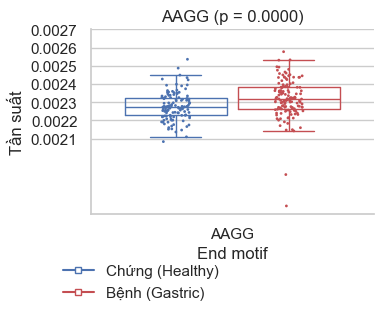

✅ Kết quả thống kê tần suất EM_AAGG:
Healthy  : Mean = 0.002278, 95% CI = [0.002264, 0.002291]
Gastric  : Mean = 0.002319, 95% CI = [0.002300, 0.002336]
📌 p-value (Mann–Whitney U test) = 2.188e-05


In [877]:
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib.lines import Line2D

# Hàm tính trung bình và khoảng tin cậy 95% (bootstrap)
def mean_ci(values, n_boot=1000, ci=0.95):
    means = []
    np.random.seed(42)
    for _ in range(n_boot):
        sample = np.random.choice(values, size=len(values), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (1 - ci) / 2 * 100)
    upper = np.percentile(means, (1 + ci) / 2 * 100)
    return np.mean(values), (lower, upper)

# 👉 1. Lọc dữ liệu cho motif AAGG
df_aagg = EM_plot2[EM_plot2['variable'].str.contains("AAGG")]

# 👉 2. Tách theo nhóm
healthy_vals = df_aagg[df_aagg["Label"] == 0]["value"]
gastric_vals = df_aagg[df_aagg["Label"] == 1]["value"]

# 👉 3. Tính trung bình và 95%CI mỗi nhóm
mean_h, ci_h = mean_ci(healthy_vals)
mean_g, ci_g = mean_ci(gastric_vals)

# 👉 4. Kiểm định Mann–Whitney
stat, p_val = mannwhitneyu(healthy_vals, gastric_vals, alternative='two-sided')

# 👉 5. Vẽ biểu đồ
plt.figure(figsize=(4, 3.5))
sb.boxplot(data=df_aagg, y='value', x='variable', hue='Label',
           palette=['b', 'r'], hue_order=[0, 1], fill=False, linewidth=1,
           flierprops=dict(marker='.', markersize=3),
           showfliers=False, dodge=True, width=0.8, gap=0.1)
sb.stripplot(data=df_aagg, y='value', x='variable', hue='Label',
             palette=['b', 'r'], hue_order=[0, 1],
             marker='.', size=4, linewidth=0, dodge=True)

plt.yticks(np.arange(0.0021, 0.0027, 0.0001))
plt.xticks(ticks=[0], labels=[em.split('_')[1] for em in df_aagg['variable'].unique()])
plt.ylabel('Tần suất')
plt.xlabel('End motif')
plt.title(f"AAGG (p = {p_val:.4f})")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 👉 6. Thêm chú thích nhóm
custom_lines = [
    Line2D([0], [0], marker='s', color='b', markerfacecolor='w', markersize=5),
    Line2D([0], [0], marker='s', color='r', markerfacecolor='w', markersize=5),
]
tys = ['Chứng (Healthy)', 'Bệnh (Gastric)']
plt.legend(custom_lines, tys, frameon=False, loc='upper right', bbox_to_anchor=(0.5, -0.2))

# 👉 7. Hiển thị dấu sao nếu có ý nghĩa
if p_val < 0.05:
    plt.text(x=0, y=max(df_aagg['value']) + 0.00002, s='', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 👉 8. In ra kết quả thống kê
print("✅ Kết quả thống kê tần suất EM_AAGG:")
print(f"Healthy  : Mean = {mean_h:.6f}, 95% CI = [{ci_h[0]:.6f}, {ci_h[1]:.6f}]")
print(f"Gastric  : Mean = {mean_g:.6f}, 95% CI = [{ci_g[0]:.6f}, {ci_g[1]:.6f}]")
print(f"📌 p-value (Mann–Whitney U test) = {p_val:.4g}")


In [878]:
# for

C:\Users\XN\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\XN\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


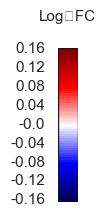

In [879]:
a=0.16
step1=0.005
Cbar=pd.DataFrame({u'log\u2082(fold change)':np.arange(a,-(a+step1),-step1)})
Cbar.index=[round(x,2) for x in Cbar[u'log\u2082(fold change)']]
plt.figure(figsize=(0.25,2))
Cbar_g=sb.heatmap(Cbar,
           cbar=False,
           cmap = matplotlib.colormaps["seismic"],
           xticklabels=False,
           )
labels=[round(i,2) for i in np.arange(a,-(a+0.04),-0.04)]
step=(len(Cbar)-1)/(len(labels)-1)
ticks=list(np.arange(0,len(Cbar),step))
plt.yticks(ticks=ticks,labels=labels)
plt.title(u'Log\u2082FC',pad=20,fontsize=11)
Cbar_g.axhline(y=0, color='k',linewidth=1)
Cbar_g.axhline(y=len(Cbar), color='k',linewidth=1)
Cbar_g.axvline(x=0, color='k',linewidth=1)
Cbar_g.axvline(x=1, color='k',linewidth=1)

FLEN distribution

In [880]:
f='FLEN'

In [881]:
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

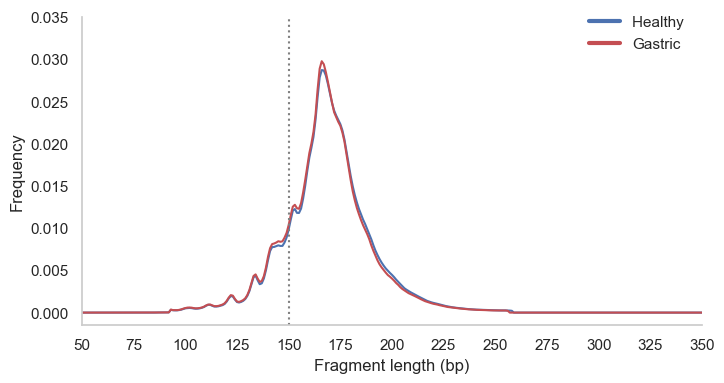

In [882]:
G={
    'Healthy':'b',
    #'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[]
# x=np.arange(100,251,1)
x=np.arange(50,351,1)

for g in list(G.keys()):
    y1=stats_fea['FLEN']['Median of '+g]
    sb.lineplot(x=x,y=y1,color=G[g],lw=1.5)
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
tys=[#'Healthy (n='+str(len(SAMPLES['Healthy']))+')',
     'Healthy ',
    # 'Gastric_benign (n='+str(len(SAMPLES['Gastric_benign']))+')',
    # 'Gastric (n='+str(len(SAMPLES['Gastric']))+')'
     'Gastric']
plt.legend(custom_lines,tys,bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
# plt.xticks(np.arange(100,275,25))
plt.xlim(50,350)
plt.xticks(np.arange(50,375,25))
plt.yticks(np.arange(0,0.04,0.005))
# plt.title('Fragment length distribution')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.savefig('.\Figure/FLEN_50-350_distribution.png', dpi=600, bbox_inches='tight')
plt.grid(False)


([<matplotlib.axis.XTick at 0x1f6c81d1c50>,
 [Text(50, 0, '50'),
  Text(75, 0, '75'),
  Text(100, 0, '100'),
  Text(125, 0, '125'),
  Text(150, 0, '150'),
  Text(175, 0, '175'),
  Text(200, 0, '200'),
  Text(225, 0, '225'),
  Text(250, 0, '250'),
  Text(275, 0, '275'),
  Text(300, 0, '300'),
  Text(325, 0, '325'),
  Text(350, 0, '350')])

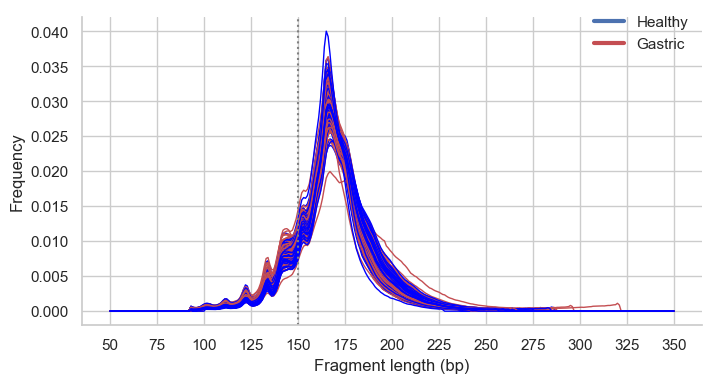

In [883]:
G2={
    'Healthy':'blue',
#    'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
#              Line2D([0], [0], color='g', lw=3),
              Line2D([0], [0], color='r', lw=3)]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)
data.reset_index(drop=True,inplace=True)

x=np.arange(50,351,1)
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,2:]
    sb.lineplot(x=x,y=y2,color=G2[g],lw=1)
#plt.legend(custom_lines,['Healthy','Gastric_benign','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.legend(custom_lines,['Healthy','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Healthy'],color='r',lw=2)
# plt.title(fea['FLEN100']['SampleID'][r])
plt.yticks(np.arange(0,0.045,0.005))
plt.xticks(np.arange(50,375,25))

In [884]:
#df=pd.DataFrame(data[data['Type']=='Healthy'])[['SampleID','FLEN_200']].sort_values(by='FLEN_200')
#df


In [885]:
#special_sample='KGDAAA09'
#G2={
#    'Healthy':'blue',
#    'Gastric_benign':'g',
#    'Gastric':'r'
#    }
#plt.figure(figsize=(8,4))
#custom_lines=[Line2D([0], [0], color='b', lw=3),
#              Line2D([0], [0], color='g', lw=3),
#              Line2D([0], [0], color='r', lw=3)]
#vector=[]
#for s in list(DATA[f]['SampleID']):
#    if s in list(sample_list_all['SampleID']):
#        vector+=[True]
#    else:
#        vector+=[False]
#data=DATA[f][vector]
#labels=[]
#for s in list(data['SampleID']):
#    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
#data.insert(loc=1,column='Type',value=labels)
#data.sort_values(by='Type',ascending=False)
#data.reset_index(drop=True,inplace=True)

#x=np.arange(50,351,1)
#for i in range(len(data)):
#    g=data['Type'][i]
#    y2=data.iloc[i,2:]
#    if data['SampleID'][i]==special_sample:
#        sb.lineplot(x=x,y=y2,color=G2[g],lw=1)
#plt.legend(custom_lines,['Healthy','Gastric_benign','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
#plt.ylabel('Frequency')
#plt.xlabel('Fragment length (bp)')
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Healthy'],color='r',lw=2)
#plt.title(special_sample)
#plt.yticks(np.arange(0,0.045,0.005))
#plt.xticks(np.arange(50,375,25))

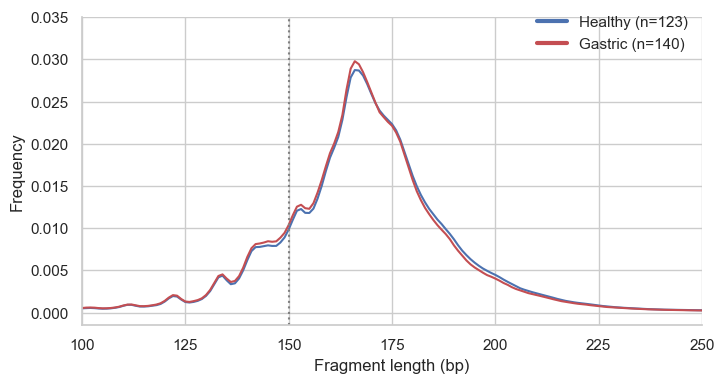

In [886]:
G={
    'Healthy':'b',
#    'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[]
# x=np.arange(100,251,1)
x=np.arange(50,351,1)

for g in list(G.keys()):
    y1=stats_fea['FLEN']['Median of '+g]
    sb.lineplot(x=x,y=y1,color=G[g],lw=1.5)
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
tys=['Healthy (n='+str(len(SAMPLES['Healthy']))+')',
#     'Gastric_benign (n='+str(len(SAMPLES['Gastric_benign']))+')',
     'Gastric (n='+str(len(SAMPLES['Gastric']))+')']
plt.legend(custom_lines,tys,bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
# plt.xticks(np.arange(100,275,25))
plt.xticks(np.arange(50,375,25))
plt.xlim(100,250)
plt.yticks(np.arange(0,0.04,0.005))
# plt.title('Fragment length distribution')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.savefig('.\Figure/FLEN_50-350_distribution.png', dpi=600, bbox_inches='tight')

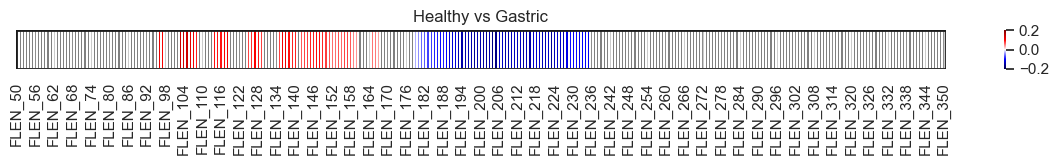

In [887]:
for p in PAIR:
    df=stats_fea['FLEN']
    set_Overlap=df[df['PADJ of '+p]<=0.05]['FEATURES']
    # df.index=df.apply(lambda row: row['FEATURES'].split('_')[1],axis=1)
    df.index=df.apply(lambda row: row['FEATURES'],axis=1)
    lst_in_out=[]
    for i in range(len(df['FEATURES'])):
        if df['FEATURES'].iloc[i] not in list(set_Overlap):
            lst_in_out+=[i]
    len(lst_in_out)

    A = df[['Log2FC Median of '+p]].T
    mask_array = np.zeros((1, df.shape[0]), dtype=bool)
    mask_array[:, lst_in_out] = True
    cmap = matplotlib.colormaps["seismic"]
    # Set the under color to white
    # cmap.set_under("yellow")
    # # Set the voer color to white
    # cmap.set_over("black")
    # Set the background color
    plt.figure(figsize=(15,0.5))
    g = sb.heatmap(A,
                    # vmin=-max([abs(min(df[col])),abs(max(df[col]))]),
                    # vmax=max([abs(min(df[col])),abs(max(df[col]))]),
                   vmin=-0.2,vmax=0.2,
                   cmap=cmap, mask=mask_array,yticklabels=False,
                   cbar=True,linewidths=0.003,linecolor='w',
                #    cbar_kws={'label': u'log\u2082(fold change)'}
                )
    # Set color of masked region
    g.set_facecolor('gray')
    g.axhline(y=0, color='k',linewidth=2)
    g.axhline(y=1, color='k',linewidth=2)
    g.axvline(x=0, color='k',linewidth=2)
    g.axvline(x=301, color='k',linewidth=2)
    g.set_title(p)
    # colorbar = g.collections[0].colorbar
    # colorbar.set_label('Colorbar Title', fontsize=12, labelpad=10)
    # colorbar.ax.invert_yaxis()
    # colorbar.set_label(u'log\u2082(fold change)', fontsize=12, rotation=0)
    # plt.title(p)
    # plt.savefig('.\Figure/FLEN_50-350_heatmap.png', dpi=600, bbox_inches='tight')

In [888]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.colors import TwoSlopeNorm

# Đọc dữ liệu
flen_df = pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_3_20250824\FLEN.csv")
meta_df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_3_20250824\Metadata_3.xlsx", sheet_name="QC", nrows=1000)

# Ghép bảng theo SampleID
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')

# Xác định cột fragment lengths từ 50 đến 350
flen_cols = [str(i) for i in range(50, 351)]



C:\Users\XN\AppData\Local\Temp\ipykernel_2928\2312371220.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


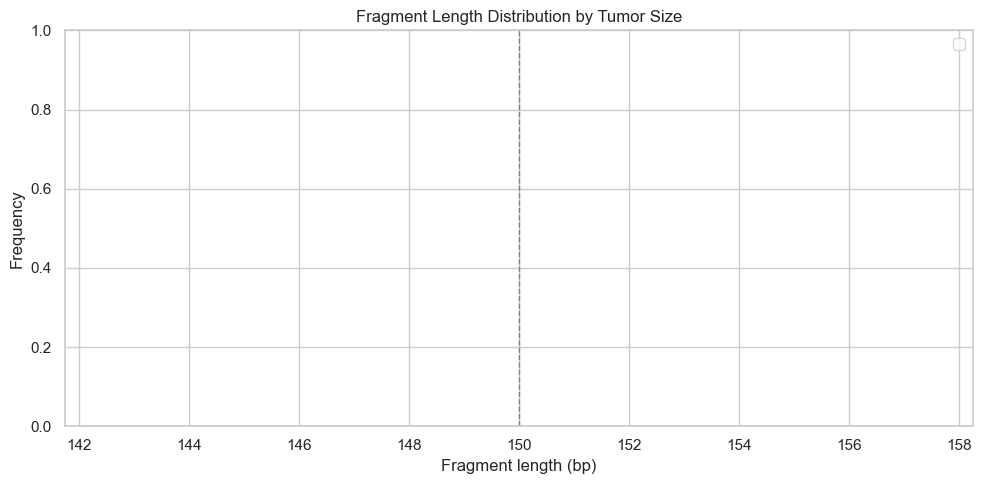

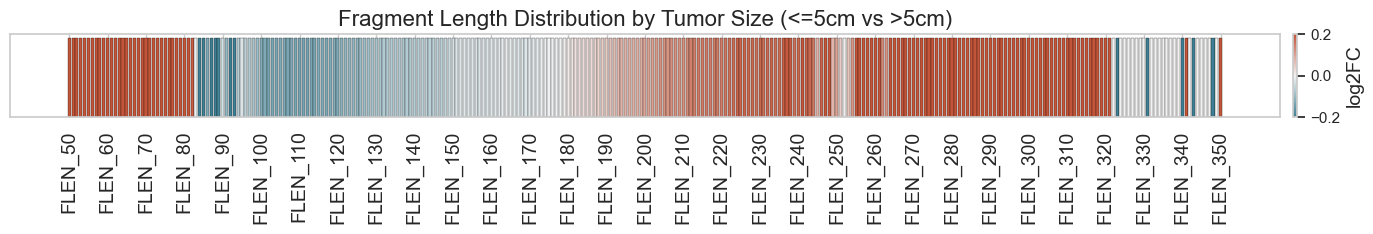

In [889]:
# Re-import necessary libraries after code execution state reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.colors import TwoSlopeNorm

# Re-load the files after reset
flen_df = pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_3_20250824\FLEN.csv")
meta_df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_3_20250824\Metadata_3.xlsx", sheet_name="QC", nrows=1000)

# Merge on SampleID
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')

# Determine fragment length columns
flen_cols = [str(i) for i in range(50, 351)]

# Filter necessary columns for "Kích thước khối u"
merged_df = merged_df[['SampleID', 'Kích thước khối u'] + flen_cols].dropna()
merged_df = merged_df.rename(columns={'Kích thước khối u': 'TumorSize'})

# Remove rows with '-' value in TumorSize
merged_df = merged_df[merged_df['TumorSize'] != '-']

# Melt data from wide to long format
flen_long = merged_df.melt(id_vars=['SampleID', 'TumorSize'], value_vars=flen_cols,
                           var_name='Length', value_name='Count')
flen_long['Length'] = flen_long['Length'].astype(int)

# Normalize by total per sample
flen_long['Total'] = flen_long.groupby('SampleID')['Count'].transform('sum')
flen_long['Freq'] = flen_long['Count'] / flen_long['Total']

# Calculate mean frequency by TumorSize and Length
grouped = flen_long.groupby(['TumorSize', 'Length'])['Freq'].mean().reset_index()

# Line plot
plt.figure(figsize=(10, 5))
sns.set(style='whitegrid')
palette = sns.color_palette(['#e41a1c', '#377eb8'])

for idx, (group, group_data) in enumerate(grouped.groupby('TumorSize')):
    plt.plot(group_data['Length'], group_data['Freq'], label=group, linewidth=2.5, color=palette[idx % len(palette)])

plt.axvline(x=150, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Fragment length (bp)')
plt.ylabel('Frequency')
plt.title('Fragment Length Distribution by Tumor Size')
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap of log2FC with larger font and Arial
fig, ax = plt.subplots(figsize=(14, 2.5))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
norm = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.2)

# Đặt font mặc định là Arial
plt.rcParams['font.family'] = 'Arial'

# Vẽ các cột biểu diễn log2FC
for i, row in stat_df.iterrows():
    color = cmap(norm(row['log2FC']))
    ax.bar(i, 1, color=color, edgecolor='black', linewidth=0.2)

# Gán nhãn trục x với cỡ chữ lớn hơn
flen_labels = [f"FLEN_{l}" for l in stat_df['Length']]
ax.set_xticks(np.arange(len(flen_labels))[::10])
ax.set_xticklabels(flen_labels[::10], rotation=90, fontsize=14)
ax.set_yticks([])

# Tiêu đề biểu đồ heatmap với tên nhóm và cỡ lớn
ax.set_title(f"{ref_group} vs {test_group}", fontsize=16, fontname='Arial')

# Thanh màu (colorbar) với cỡ chữ lớn hơn
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('log2FC', fontsize=14)

# Tiêu đề tổng thể
plt.title('Fragment Length Distribution by Tumor Size (<=5cm vs >5cm)',
          fontsize=16, fontname='Arial')

plt.tight_layout()
plt.show()

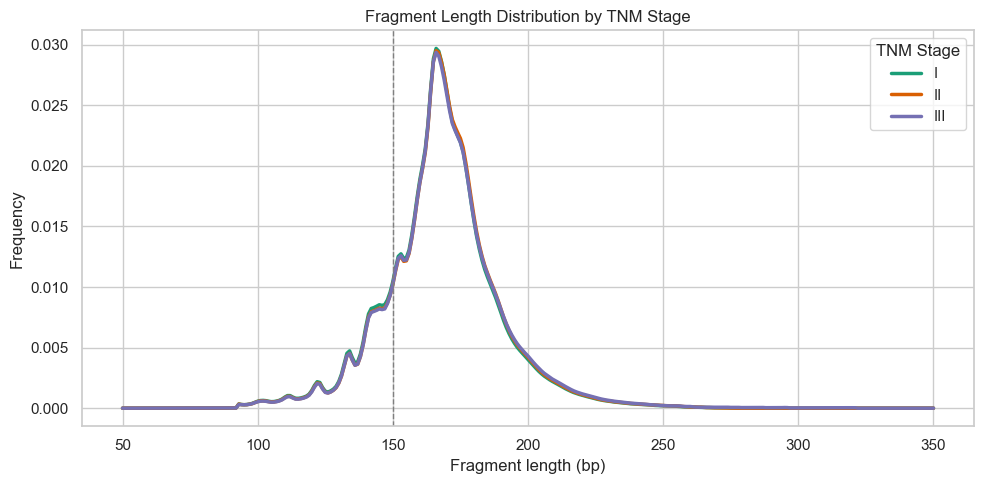

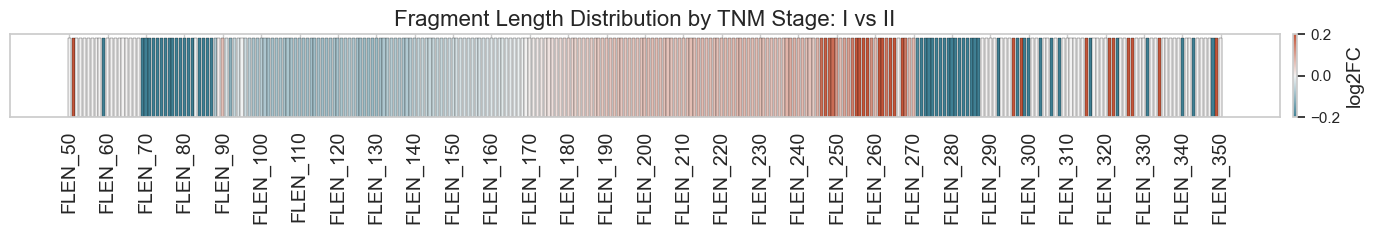

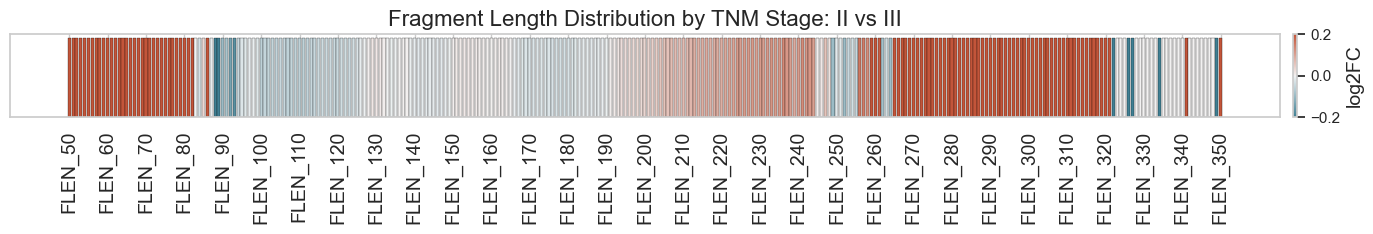

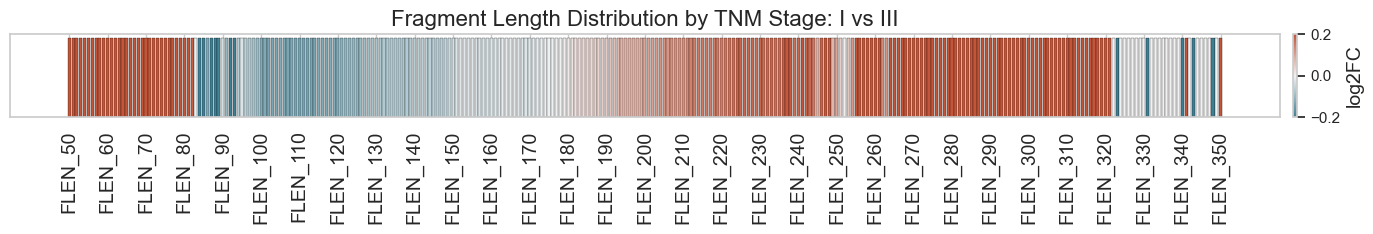

In [890]:
import itertools

# Dữ liệu ban đầu giống như trước, chỉ thay thế cột phân nhóm
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')
flen_cols = [str(i) for i in range(50, 351)]
merged_df = merged_df[['SampleID', 'Giai đoạn theo TNM'] + flen_cols].dropna()
merged_df = merged_df.rename(columns={'Giai đoạn theo TNM': 'TNMStage'})

# Loại bỏ giá trị không hợp lệ
merged_df = merged_df[merged_df['TNMStage'].isin(['I', 'II', 'III'])]

# Long format
flen_long = merged_df.melt(id_vars=['SampleID', 'TNMStage'], value_vars=flen_cols,
                           var_name='Length', value_name='Count')
flen_long['Length'] = flen_long['Length'].astype(int)
flen_long['Total'] = flen_long.groupby('SampleID')['Count'].transform('sum')
flen_long['Freq'] = flen_long['Count'] / flen_long['Total']

# Biểu đồ đường tổng quát theo TNM
grouped = flen_long.groupby(['TNMStage', 'Length'])['Freq'].mean().reset_index()

plt.figure(figsize=(10, 5))
palette = sns.color_palette(['#1b9e77', '#d95f02', '#7570b3'])
for idx, (stage, data) in enumerate(grouped.groupby('TNMStage')):
    plt.plot(data['Length'], data['Freq'], label=stage, linewidth=2.5, color=palette[idx])
plt.axvline(x=150, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Fragment length (bp)')
plt.ylabel('Frequency')
plt.title('Fragment Length Distribution by TNM Stage')
plt.legend(title="TNM Stage")
plt.tight_layout()
plt.show()

# Heatmap log2FC cho từng cặp: I vs II, II vs III, I vs III
pair_results = {}

# Cài đặt font mặc định là Arial
plt.rcParams['font.family'] = 'Arial'

for ref_stage, test_stage in [('I', 'II'), ('II', 'III'), ('I', 'III')]:
    # Pivot dữ liệu
    pivot_df = grouped[grouped['TNMStage'].isin([ref_stage, test_stage])] \
        .pivot(index='Length', columns='TNMStage', values='Freq').fillna(0)

    epsilon = 1e-9
    log2fc = np.log2((pivot_df[test_stage] + epsilon) / (pivot_df[ref_stage] + epsilon))

    p_values = []
    log2fc_values = []

    for length in range(50, 351):
        ref_vals = flen_long[(flen_long['TNMStage'] == ref_stage) & (flen_long['Length'] == length)]['Freq'].dropna()
        test_vals = flen_long[(flen_long['TNMStage'] == test_stage) & (flen_long['Length'] == length)]['Freq'].dropna()
        if len(ref_vals) > 0 and len(test_vals) > 0:
            stat, p = mannwhitneyu(test_vals, ref_vals, alternative='two-sided')
            lfc = np.log2((test_vals.mean() + epsilon) / (ref_vals.mean() + epsilon))
        else:
            p = np.nan
            lfc = 0
        p_values.append(p)
        log2fc_values.append(lfc)

    stat_df = pd.DataFrame({
        'Length': list(range(50, 351)),
        'log2FC': log2fc_values,
        'p-value': p_values
    })
    stat_df['Significance'] = ['p < 0.05' if p < 0.05 else 'n.s.' for p in stat_df['p-value']]
    pair_results[f"{ref_stage} vs {test_stage}"] = stat_df

    # Vẽ heatmap
    fig, ax = plt.subplots(figsize=(14, 2.5))
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    norm = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.2)

    for i, row in stat_df.iterrows():
        color = cmap(norm(row['log2FC']))
        ax.bar(i, 1, color=color, edgecolor='black', linewidth=0.2)

    flen_labels = [f"FLEN_{l}" for l in stat_df['Length']]
    ax.set_xticks(np.arange(len(flen_labels))[::10])
    ax.set_xticklabels(flen_labels[::10], rotation=90, fontsize=14)
    ax.set_yticks([])

    # Tiêu đề biểu đồ heatmap với Arial và kích thước lớn
    ax.set_title(f"Fragment Length Distribution by TNM Stage: {ref_stage} vs {test_stage}", fontsize=16, fontname='Arial')

    # Thêm colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label('log2FC', fontsize=14)

    plt.tight_layout()
    plt.show()


NFP distribution

In [891]:
f='NFP'

In [892]:
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

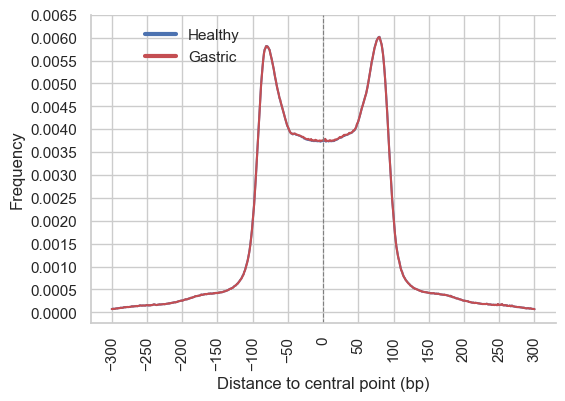

In [893]:
G={
    'Healthy':'b',
    #'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(6,4))
custom_lines=[]
x=np.arange(-300,301,1)

for g in list(G.keys()):
    y1=stats_fea['NFP']['Median of '+g]
    ax=sb.lineplot(x=x,y=y1,color=G[g])
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.legend(custom_lines,G,bbox_to_anchor=(0.35, 1.),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.007,0.0005))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')

# plt.savefig('.\Figure/NFP_distribution.png', dpi=600, bbox_inches='tight')

C:\Users\XN\AppData\Local\Temp\ipykernel_2928\3160854511.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='order',ascending=True,inplace=True)


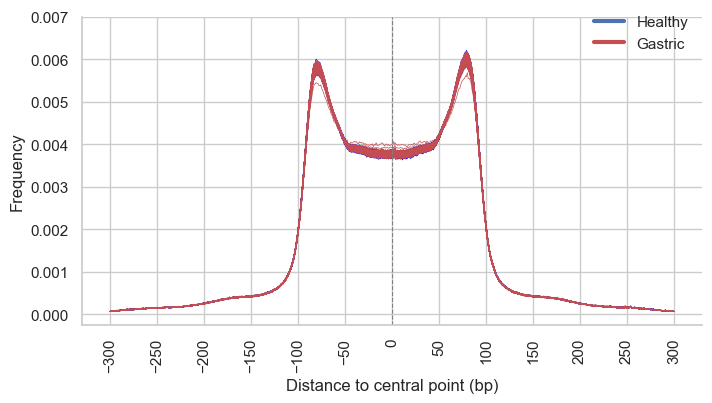

In [894]:
G2={
    'Healthy':'blue',
    'Gastric':'r',
    #'Gastric_benign':'g',   
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
              Line2D([0], [0], color='r', lw=3),
              Line2D([0], [0], color='g', lw=3)
              ]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)

order=[]
for s in list(data['SampleID']):
    if list(data[data['SampleID']==s]['Type'])[0]=='Healthy':
        order+=[0]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric':
        order+=[1]
    #elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric_benign':
    #    order+=[2]
data.insert(loc=1,column='order',value=order)
data.sort_values(by='order',ascending=True,inplace=True)          
data.reset_index(drop=True,inplace=True)

x=np.arange(-300,301,1)

# for g in list(G.keys()):
#     y1=stats_fea['NFP']['Mean of '+g]
#     ax=sb.lineplot(x=x,y=y1,color=G[g],lw=2)
#     custom_lines += [Line2D([0], [0], color=G[g], lw=3)]
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,3:]
    sb.lineplot(x=x,y=y2,color=G2[g],lw=0.5)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Healthy'],color='r',lw=2)

#plt.legend(custom_lines,['Healthy','Gastric','Gastric_benign'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.legend(custom_lines,['Healthy','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.008,0.001))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# square=patches.Rectangle((0.003, 0.003), 0.006, 0.006, edgecolor='orange', facecolor='none')
# ax.add_patch(square)
# plt.title('Nucleosome footprint partern')
# plt.savefig('.\Figure/NFP_distribution_all.png', dpi=600, bbox_inches='tight')

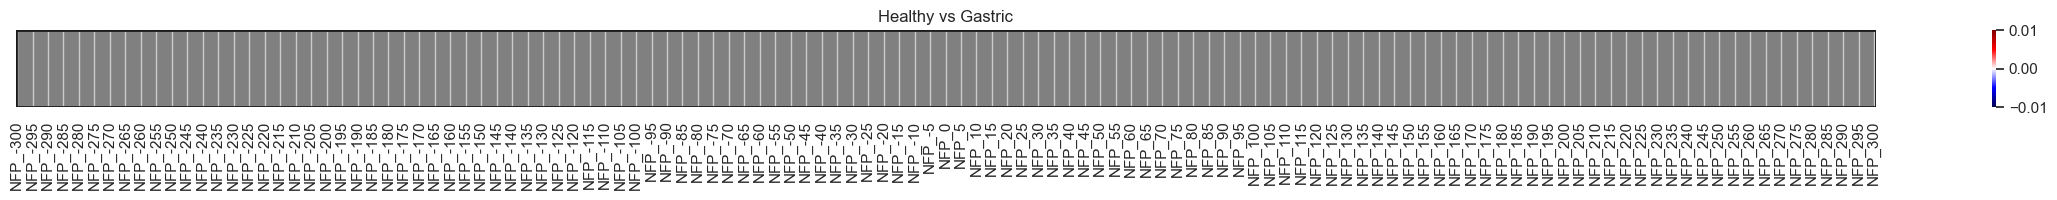

In [895]:
for p in PAIR:
    df=stats_fea['NFP']
    set_Overlap=df[df['PADJ of '+p]<=0.05]['FEATURES']
    # df.index=df.apply(lambda row: row['FEATURES'].split('_')[1],axis=1)
    df.index=df.apply(lambda row: row['FEATURES'],axis=1)
    lst_in_out=[]
    for i in range(len(df['FEATURES'])):
        if df['FEATURES'].iloc[i] not in list(set_Overlap):
            lst_in_out+=[i]
    len(lst_in_out)

    A = df[['Log2FC Median of '+p]].T
    mask_array = np.zeros((1, df.shape[0]), dtype=bool)
    mask_array[:, lst_in_out] = True
    cmap = matplotlib.colormaps["seismic"]
    # Set the under color to white
    # cmap.set_under("yellow")
    # # Set the voer color to white
    # cmap.set_over("black")
    # Set the background color
    plt.figure(figsize=(30,1))
    g = sb.heatmap(A,
                    # vmin=-max([abs(min(df[col])),abs(max(df[col]))]),
                    # vmax=max([abs(min(df[col])),abs(max(df[col]))]),
                   vmin=-0.01,vmax=0.01,
                   cmap=cmap, mask=mask_array,yticklabels=False,
                   cbar=True,linewidths=0.00,linecolor='w',
                #    cbar_kws={'label': u'log\u2082(fold change)'}
                )
    # Set color of masked region
    g.set_facecolor('gray')
    g.axhline(y=0, color='k',linewidth=2)
    g.axhline(y=1, color='k',linewidth=2)
    g.axvline(x=0, color='k',linewidth=2)
    g.axvline(x=601, color='k',linewidth=2)
    g.set_title(p)
    # colorbar = g.collections[0].colorbar
    # colorbar.set_label('Colorbar Title', fontsize=12, labelpad=10)
    # colorbar.ax.invert_yaxis()
    # colorbar.set_label(u'log\u2082(fold change)', fontsize=12, rotation=0)
    # plt.title(p)
    # plt.savefig('.\Figure/FLEN_50-350_heatmap.png', dpi=600, bbox_inches='tight')

In [896]:
df=pd.DataFrame(data[data['Type']=='Healthy'])[['SampleID','NFP_75']].sort_values(by='NFP_75')
df

,SampleID,NFP_75
65,HNGH020,0.005672
45,HNGH073,0.005724
84,HNGH124,0.005730
67,HNGH097,0.005731
9,HNGH037,0.005736
...,...,...
55,HNGH056,0.005979
95,HNGH113,0.005981
94,HNGH114,0.005983
6,HNGH043,0.005997


C:\Users\XN\AppData\Local\Temp\ipykernel_2928\1935119429.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='order',ascending=True,inplace=True)


Text(0.5, 1.0, 'KGDAAA09')

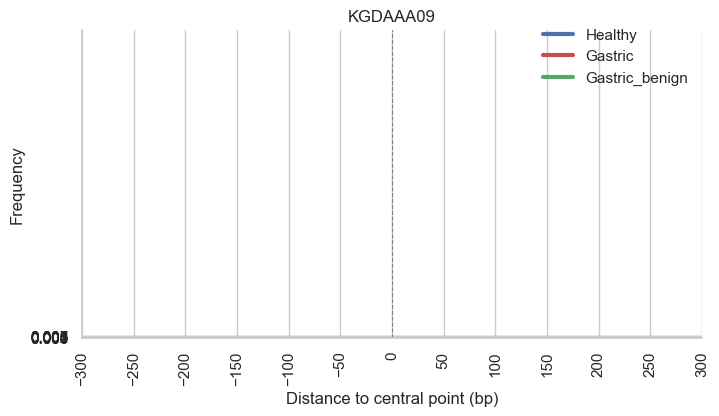

In [897]:
special_sample='KGDAAA09'
G2={
    'Healthy':'blue',
    'Gastric':'r',
    'Gastric_benign':'g'
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
              Line2D([0], [0], color='r', lw=3),
              Line2D([0], [0], color='g', lw=3)
              ]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)

order=[]
for s in list(data['SampleID']):
    if list(data[data['SampleID']==s]['Type'])[0]=='Healthy':
        order+=[0]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric':
        order+=[1]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric_benign':
        order+=[2]
data.insert(loc=1,column='order',value=order)
data.sort_values(by='order',ascending=True,inplace=True)          
data.reset_index(drop=True,inplace=True)

x=np.arange(-300,301,1)

# for g in list(G.keys()):
#     y1=stats_fea['NFP']['Mean of '+g]
#     ax=sb.lineplot(x=x,y=y1,color=G[g],lw=2)
#     custom_lines += [Line2D([0], [0], color=G[g], lw=3)]
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,3:]
    if data['SampleID'][i]==special_sample:
        sb.lineplot(x=x,y=y2,color=G2[g],lw=0.5)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Healthy'],color='r',lw=2)

plt.legend(custom_lines,['Healthy','Gastric','Gastric_benign'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.008,0.001))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# square=patches.Rectangle((0.003, 0.003), 0.006, 0.006, edgecolor='orange', facecolor='none')
# ax.add_patch(square)
plt.title(special_sample)
# plt.savefig('.\Figure/NFP_distribution_all.png', dpi=600, bbox_inches='tight')

CNA bins

In [898]:
def vectorcolor(p,f):
    data_split=stats_fea[f]
    # data_concatenate=stats_fea['All_features']
    col_PADJ='PADJ of '+p
    col_L2FC='Log2FC of '+p
    cols=[]
    for i in list(data_split.iloc[:,0]):
        PADJ_split=data_split[data_split[data_split.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
        # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]

        L2FC_split=data_split[data_split[data_split.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]

        if L2FC_split <0 and PADJ_split<=0.05:
            cols.append('b')
        elif L2FC_split >=0 and PADJ_split<=0.05:
            cols.append('red')
        elif PADJ_split>0.05:
            cols.append('gray')
    return cols

In [899]:
#Tạo position cho chromosome
Chromosome=[]
for i in range(len(stats_fea['CNA'])):
    chromosome=int(stats_fea['CNA']['FEATURES'].iloc[i].split(":")[0].split("_")[1])
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
results

,Count,Vline,Position
Chromosome,,,
1,159,159,39
2,162,321,240
3,148,469,395
4,140,609,539
5,136,745,677
6,120,865,805
7,111,976,920
8,108,1084,1030
9,83,1167,1125


C:\Users\XN\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\XN\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


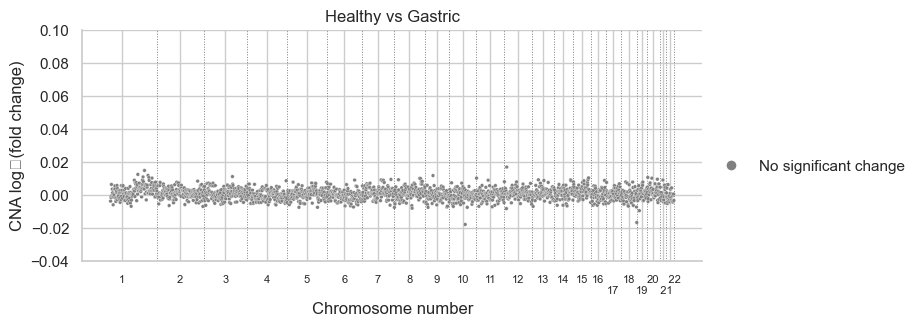

In [900]:
f='CNA'
custom_lines = [
    # Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=8,mec='w'),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='gray', markersize=8,mec='w'),
                    # Line2D([0], [0],marker='o', color='w', markerfacecolor='b', markersize=8,mec='w'),
                    ]
data=stats_fea[f]
for p in PAIR:
    col_log='Log2FC of '+p
    if col_log not in data.columns:
        col_log='Distance of '+p
    col_PADJ='PADJ of '+p 
    cols=vectorcolor(p,f)

    plt.figure(figsize=(8, 3))
    # plt.figure(figsize=(6/1.4,3/1.5))
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','\n17','18','\n19','20','\n  21','   22']
    x=data['FEATURES']
    y=data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
        
    sb.scatterplot(x=x,y=y,c=cols,s=7,edgecolor='w')
    # lst_name_show=["CNA_10:135000001-135534747"]
    # region_name = list(data['FEATURES'])
    # for i, txt in enumerate(region_name):
    #     if txt in lst_name_show:
    #         plt.text(x[i],y[i],txt,fontsize=8,color='red')
   
    
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(-0.04,0.1,0.02))
    plt.xlabel('Chromosome number')
    plt.ylabel('CNA '+u'log\u2082(fold change)')
    plt.title(p)
    # n_gain=pd.DataFrame(cols)[0].value_counts()['red']
    # n_loss=pd.DataFrame(cols)[0].value_counts()['b']
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['No significant change'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\CNA_bins.png', dpi=600, bbox_inches='tight')

SCNA bins

C:\Users\XN\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\XN\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


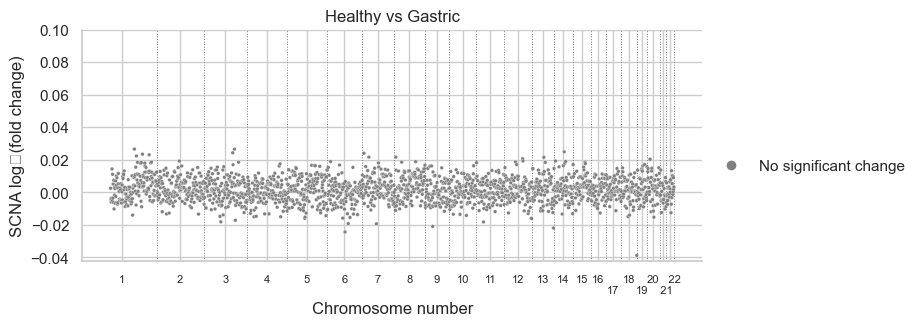

In [901]:
f='SCNA'
custom_lines = [
    # Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=8,mec='w'),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='gray', markersize=8,mec='w'),
                    # Line2D([0], [0],marker='o', color='w', markerfacecolor='b', markersize=8,mec='w'),
                    ]
data=stats_fea[f]
for p in PAIR:
    col_log='Log2FC of '+p
    if col_log not in data.columns:
        col_log='Distance of '+p
    col_PADJ='PADJ of '+p 
    cols=vectorcolor(p,f)

    plt.figure(figsize=(8, 3))
    # plt.figure(figsize=(6/1.4,3/1.5))
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','\n17','18','\n19','20','\n  21','   22']
    x=data['FEATURES']
    y=data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
        
    sb.scatterplot(x=x,y=y,c=cols,s=7,edgecolor='w')
    # lst_name_show=["CNA_10:135000001-135534747"]
    # region_name = list(data['FEATURES'])
    # for i, txt in enumerate(region_name):
    #     if txt in lst_name_show:
    #         plt.text(x[i],y[i],txt,fontsize=8,color='red')
   
    
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(-0.04,0.1,0.02))
    plt.xlabel('Chromosome number')
    plt.ylabel('SCNA '+u'log\u2082(fold change)')
    plt.title(p)
    # n_gain=pd.DataFrame(cols)[0].value_counts()['red']
    # n_loss=pd.DataFrame(cols)[0].value_counts()['b']
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['No significant change'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\CNA_bins.png', dpi=600, bbox_inches='tight')

RATIOSL

In [902]:
#Tạo position cho chromosome
GWFP=stats_fea['RATIOSL']
GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
Chromosome=[]
for i in range(len(GWFP)):
    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
    chromosome=int(chromosome)
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
results

,Count,Vline,Position
Chromosome,,,
1,230,230,57
2,241,471,350
3,196,667,569
4,190,857,762
5,178,1035,946
6,165,1200,1117
7,158,1358,1279
8,144,1502,1430
9,117,1619,1560



📊 Healthy vs Gastric:
  Healthy - Mean: 0.1825, Median: 0.1787, Min: 0.1576, Max: 0.3409
  Gastric - Mean: 0.1952, Median: 0.1913, Min: 0.1691, Max: 0.3529
  🔥 Mann-Whitney U test: p = 9.599e-256
  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.


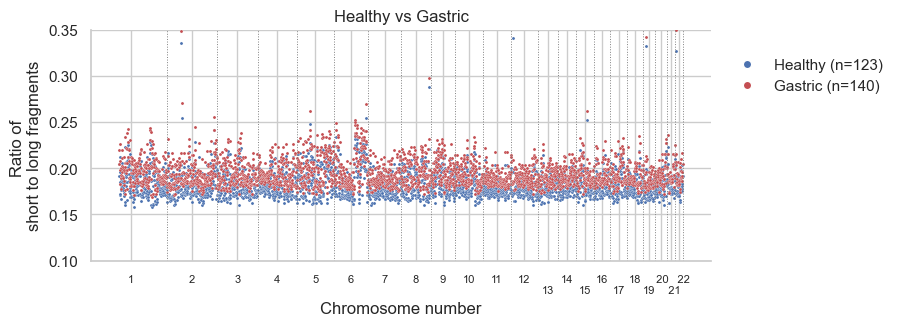

In [903]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to long fragments')
    plt.title(p)
    #custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    #plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric (n='+str(len(gastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

    group1_values = GWFP[col1].dropna()
    group2_values = GWFP[col2].dropna()
     # ✅ Sau khi vẽ, in thống kê và kết luận
    mean1, mean2 = group1_values.mean(), group2_values.mean()
    median1, median2 = group1_values.median(), group2_values.median()
    min1, min2 = group1_values.min(), group2_values.min()
    max1, max2 = group1_values.max(), group2_values.max()

    print(f"\n📊 {p}:")
    print(f"  {p.split(' vs ')[0]} - Mean: {mean1:.4f}, Median: {median1:.4f}, Min: {min1:.4f}, Max: {max1:.4f}")
    print(f"  {p.split(' vs ')[1]} - Mean: {mean2:.4f}, Median: {median2:.4f}, Min: {min2:.4f}, Max: {max2:.4f}")

    # ✅ Kiểm định thống kê giữa 2 nhóm
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    print(f"  🔥 Mann-Whitney U test: p = {p_value:.4g}")

    # ✅ Kết luận
    if p_value < 0.05:
        print("  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")
    else:
        print("  ❌ Kết luận: Không có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")



RATIOST

In [904]:
#Tạo position cho chromosome
GWFP=stats_fea['RATIOST']
GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
Chromosome=[]
for i in range(len(GWFP)):
    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
    chromosome=int(chromosome)
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
# results


📊 Healthy vs Gastric:
  Healthy - Mean: 0.1537, Median: 0.1511, Min: 0.1357, Max: 0.2535
  Gastric - Mean: 0.1623, Median: 0.1597, Min: 0.1439, Max: 0.2597
  🔥 Mann-Whitney U test: p = 8.022e-244
  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.


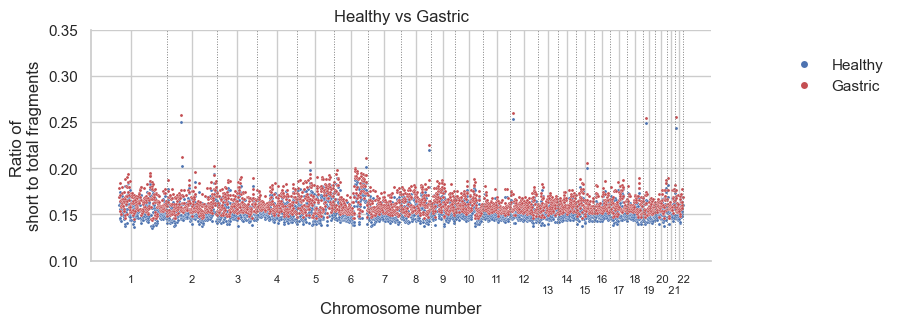

In [905]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to total fragments')
    plt.title(p)
    #custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    #plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.legend(custom_lines,['Healthy','Gastric'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

    group1_values = GWFP[col1].dropna()
    group2_values = GWFP[col2].dropna()
     # ✅ Sau khi vẽ, in thống kê và kết luận
    mean1, mean2 = group1_values.mean(), group2_values.mean()
    median1, median2 = group1_values.median(), group2_values.median()
    min1, min2 = group1_values.min(), group2_values.min()
    max1, max2 = group1_values.max(), group2_values.max()

    print(f"\n📊 {p}:")
    print(f"  {p.split(' vs ')[0]} - Mean: {mean1:.4f}, Median: {median1:.4f}, Min: {min1:.4f}, Max: {max1:.4f}")
    print(f"  {p.split(' vs ')[1]} - Mean: {mean2:.4f}, Median: {median2:.4f}, Min: {min2:.4f}, Max: {max2:.4f}")

    # ✅ Kiểm định thống kê giữa 2 nhóm
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    print(f"  🔥 Mann-Whitney U test: p = {p_value:.4g}")

    # ✅ Kết luận
    if p_value < 0.05:
        print("  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")
    else:
        print("  ❌ Kết luận: Không có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")

In [906]:
# ✅ LẤY DANH SÁCH CÁC CỘT TÍNH TOÁN (KHÔNG GỒM CỘT PHÂN NHÓM)
#columns = [col for col in df.columns if col != 'Giai đoạn theo TNM']

# -----------------------------
# TÍNH LOG2FC & P-VALUE
# -----------------------------
#results = []
#for feature in columns:
#    group_I = df[df['Giai đoạn theo TNM'] == 'I'][feature]
#    group_II = df[df['Giai đoạn theo TNM'] == 'II'][feature]

#   mean_I = group_I.mean()
#    mean_II = group_II.mean()
#    log2fc = np.log2((mean_II + 1e-9) / (mean_I + 1e-9))
#    _, p_val = ttest_ind(group_II, group_I, equal_var=False)

#    results.append({
#        'FEATURE': feature,
#        'Log2FC': log2fc,
#        'p-value': p_val
#    })

#results_df = pd.DataFrame(results)

# -----------------------------
# VẼ HEATMAP (GIỮ ĐÚNG VỊ TRÍ, CHỈ HIỂN THỊ P < 0.05)
# -----------------------------
#sorted_all = results_df.sort_values(by='p-value', ascending=True).reset_index(drop=True)
#log2fc_vals = sorted_all['Log2FC'].values
#features = sorted_all['FEATURE'].values
#pvals = sorted_all['p-value'].values

#masked_vals = [val if p < 0.05 else np.nan for val, p in zip(log2fc_vals, pvals)]
#masked_df = pd.DataFrame([masked_vals], columns=features, index=['Log₂FC'])

#plt.figure(figsize=(12, 2))
#sb.heatmap(masked_df,
#           cmap='seismic', center=0,
#           vmin=-0.16, vmax=0.16,
#           linewidths=1,
#           xticklabels=True, yticklabels=True,
#           cbar_kws={'label': 'Log₂FC'})
#plt.xticks(rotation=90)
#plt.title('Log₂FC heatmap (features with p < 0.05 only)', fontsize=12)
#plt.tight_layout()
#plt.show()

In [907]:
stats_fea['RATIOSL']

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,RATIOSL_1:1-1000000,0.205008,0.219332,0.201369,0.213431,0.035692,0.041412,17.409976,18.880923,3.458378,...,0.097436,0.083935,0.006024,0.012639,0.21,0.22,1.898302,0.014324,0.600240,0.600240
1,RATIOSL_1:100000001-101000000,0.191636,0.204663,0.188369,0.198440,0.031527,0.041840,16.451670,20.443265,3.380807,...,0.094879,0.075144,0.009484,0.013365,0.19,0.20,1.874042,0.013027,0.594680,0.594680
2,RATIOSL_1:10000001-11000000,0.195487,0.208163,0.192054,0.205543,0.031311,0.039720,16.016697,19.081009,3.422048,...,0.090641,0.097926,0.009155,0.013239,0.20,0.21,1.878153,0.012676,0.595122,0.595122
3,RATIOSL_1:1000001-2000000,0.211706,0.226308,0.208520,0.223584,0.033214,0.040317,15.688720,17.815259,3.561613,...,0.096229,0.100626,0.004439,0.012639,0.21,0.23,1.898302,0.014603,0.603842,0.603842
4,RATIOSL_1:101000001-102000000,0.185613,0.198340,0.181669,0.195976,0.030718,0.039298,16.549484,19.813739,3.443223,...,0.095678,0.109366,0.006904,0.012639,0.19,0.20,1.898302,0.012727,0.598597,0.598597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2867,RATIOSL_Y:10000001-11000000,0.245546,0.252234,0.241767,0.251407,0.051408,0.055986,20.936073,22.195905,3.524920,...,0.038766,0.056408,0.277352,0.277642,0.25,0.25,0.556515,0.006687,0.539647,0.539647
2868,RATIOSL_Y:13000001-14000000,0.489802,0.489456,0.463164,0.465633,0.121653,0.118463,24.837121,24.203045,3.670706,...,-0.001020,0.007669,0.941350,0.941350,0.49,0.49,0.026249,-0.000346,0.502685,0.497315
2869,RATIOSL_Y:58000001-59000000,0.339637,0.353646,0.333947,0.348696,0.059760,0.064362,17.595152,18.199552,3.552913,...,0.058311,0.062351,0.073038,0.073370,0.34,0.35,1.134479,0.014009,0.565426,0.565426
2870,RATIOSL_Y:59000001-59373566,0.199403,0.215508,0.196250,0.213873,0.046415,0.052263,23.277259,24.251019,3.566836,...,0.112053,0.124061,0.015701,0.017656,0.20,0.22,1.753117,0.016105,0.588172,0.588172


In [908]:
GWFP

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,RATIOST_1:1-1000000,0.169415,0.178942,0.167616,0.175891,0.024169,0.027609,14.266041,15.429036,3.576212,...,0.078932,0.069521,0.006024,0.012647,0.17,0.18,1.898000,0.009527,0.600240,0.600240
1,RATIOST_1:100000001-101000000,0.160242,0.168907,0.158510,0.165582,0.021801,0.028394,13.604941,16.810562,3.412126,...,0.075984,0.062968,0.009484,0.013374,0.16,0.17,1.873739,0.008666,0.594680,0.594680
2,RATIOST_1:10000001-11000000,0.162954,0.171416,0.161112,0.170498,0.021654,0.026820,13.288581,15.645868,3.447148,...,0.073039,0.081693,0.009155,0.013248,0.16,0.17,1.877851,0.008462,0.595122,0.595122
3,RATIOST_1:1000001-2000000,0.174104,0.183678,0.172542,0.182729,0.022393,0.026391,12.861992,14.368200,3.523093,...,0.077229,0.082755,0.004439,0.012647,0.17,0.18,1.898000,0.009574,0.603842,0.603842
4,RATIOST_1:101000001-102000000,0.155994,0.164620,0.153739,0.163863,0.021629,0.027219,13.865435,16.534310,3.472907,...,0.077648,0.092004,0.006904,0.012647,0.16,0.16,1.898000,0.008626,0.598597,0.598597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2713,RATIOST_9:95000001-96000000,0.168799,0.177418,0.168038,0.177029,0.020978,0.026783,12.427504,15.095978,3.446078,...,0.071849,0.075195,0.007123,0.012647,0.17,0.18,1.898000,0.008619,0.598218,0.598218
2714,RATIOST_9:96000001-97000000,0.152261,0.159794,0.149965,0.158673,0.021543,0.025598,14.148694,16.019344,3.347777,...,0.069675,0.081428,0.014132,0.016464,0.15,0.16,1.783472,0.007534,0.589562,0.589562
2715,RATIOST_9:97000001-98000000,0.153733,0.163076,0.150647,0.163427,0.022083,0.026647,14.364300,16.340183,3.554454,...,0.085115,0.117471,0.004415,0.012647,0.15,0.16,1.898000,0.009343,0.603905,0.603905
2716,RATIOST_9:98000001-99000000,0.148575,0.156512,0.146518,0.154768,0.021327,0.026071,14.354239,16.657363,3.384598,...,0.075089,0.079032,0.014616,0.016802,0.15,0.16,1.774637,0.007938,0.589120,0.589120


CLE

In [909]:
#Tạo position cho chromosome
#GWFP=stats_fea['CLE']
#GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
#Chromosome=[]
#for i in range(len(GWFP)):
#    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
#    chromosome=int(chromosome)
#    Chromosome+=[chromosome]
#results=pd.DataFrame({'Chromosome':Chromosome})
#results=results['Chromosome'].value_counts().sort_index()
#results=pd.DataFrame({'Count':results})
#lst=[]
#for i in range(len(results)):
#    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
#    lst+=[sum(results.iloc[:i+1,0])]
#results['Vline']=lst

#Position=[]
#for i in range(1,23,1):
#    if i ==1:
#        posit=int(results['Vline'][i]/4)
#    else:
#        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
#    Position+=[posit]
#results['Position']=Position
#results

NameError: name 'gastric_benign' is not defined

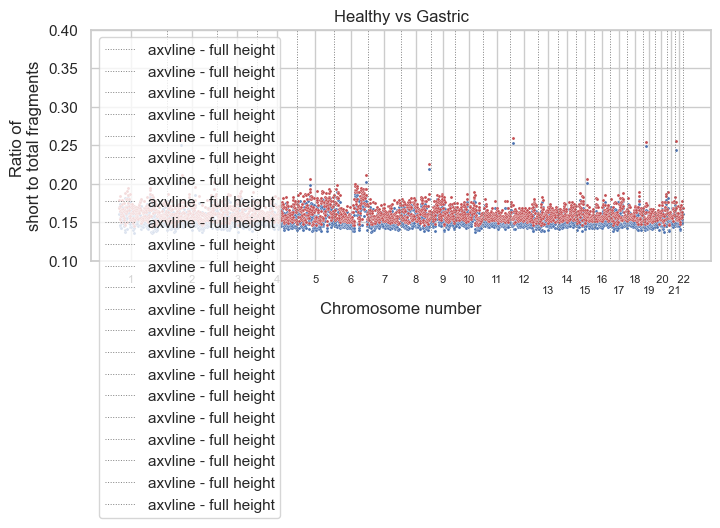

In [910]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    #col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    # plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to total fragments')
    plt.title(p)
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

PCA

In [ ]:
G={
    'Healthy':'b',
    'Gastric_benign':'g',
    'Gastric':'r'
    }

In [ ]:
special_samples=['KGDAAA09','MG168','ZK0AAAI07NB','ZMG050NB']
special_samples

['KGDAAA09', 'MG168', 'ZK0AAAI07NB', 'ZMG050NB']

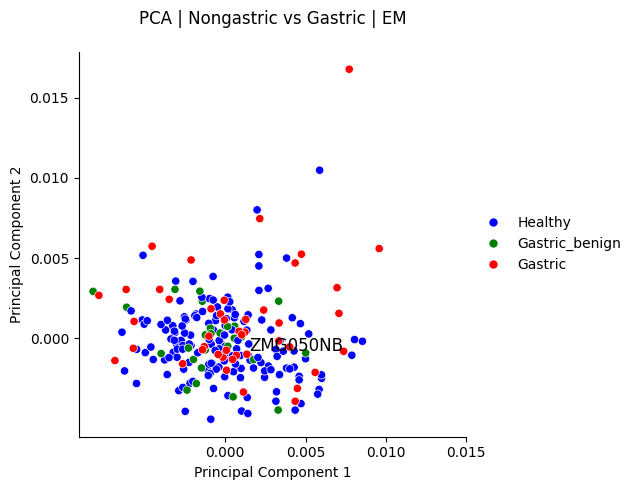

In [ ]:
f='EM'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[0,0.02,0.005],xticks=[0,0.02,0.005],
      save=False,figname='PCA.png'
            )

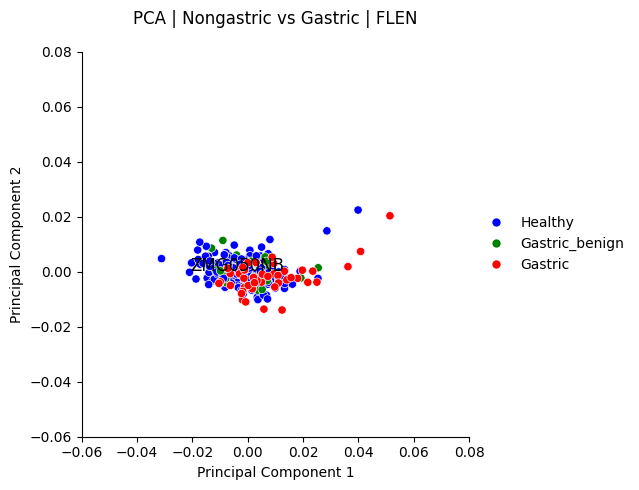

In [ ]:
f='FLEN'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.06,0.08,0.02],xticks=[-0.06,0.08,0.02],
      save=False,figname='PCA.png'
            )

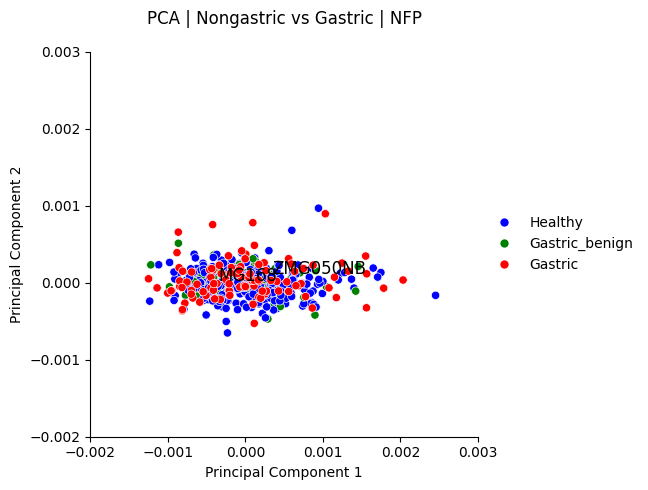

In [ ]:
f='NFP'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.002,0.004,0.001],xticks=[-0.002,0.004,0.001],
      save=False,figname='PCA.png'
            )

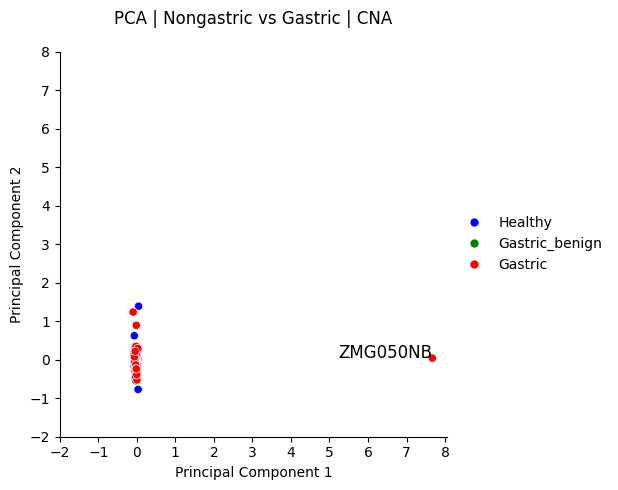

In [ ]:
f='CNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

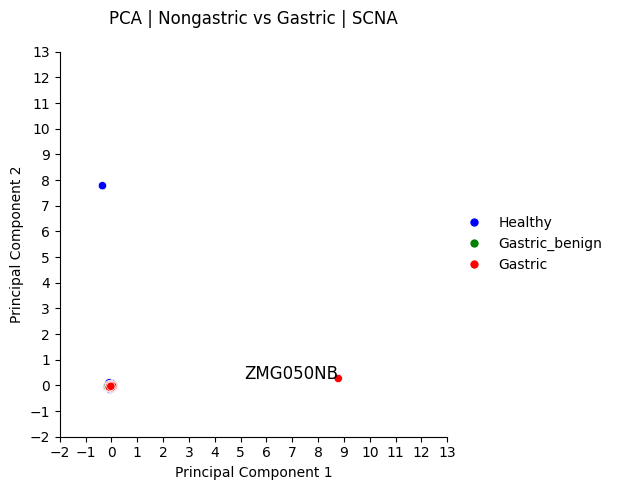

In [ ]:
f='SCNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,14,1],xticks=[-2,14,1],
      save=False,figname='PCA.png'
            )

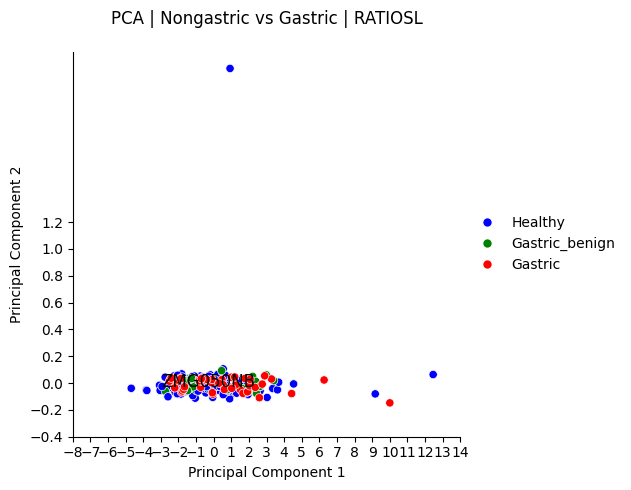

In [ ]:
f='RATIOSL'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.4,1.4,0.2],xticks=[-8,15,1],
      save=False,figname='PCA.png'
            )

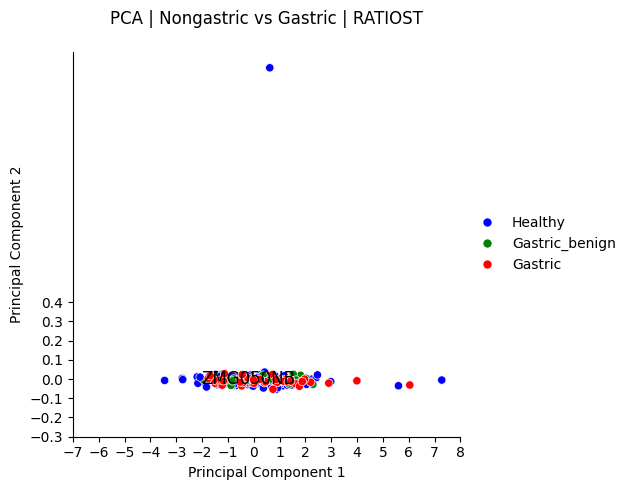

In [ ]:
f='RATIOST'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.3,0.5,0.1],xticks=[-7,9,1],
      save=False,figname='PCA.png'
            )

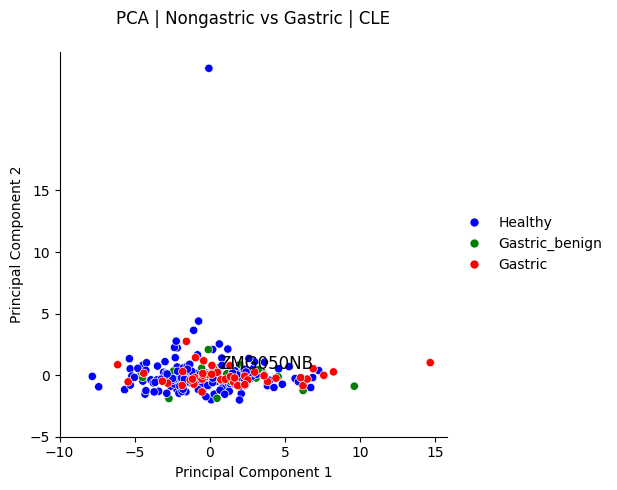

In [ ]:
f='CLE'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-5,20,5],xticks=[-10,20,5],
      save=False,figname='PCA.png'
            )

PCA filter

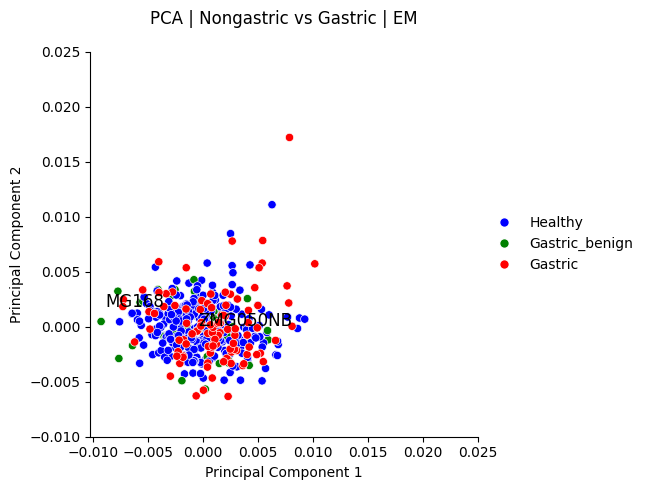

In [ ]:
f='EM'
healthy1=healthy[~healthy.iloc[:, 0].str.contains(special_sample, na=False)]
Nongastric1=pd.concat([healthy1,gastric_benign],axis=0)
PCAsigfea(
        DATA,
        SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
        stats_fea=stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        p='Nongastric vs Gastric',
        f=f,
        sig=False,alpha=0.05,
        show_ID=True,IDs=special_samples,
        plot_pct_explain=False,top_pc=2,
        yticks=[-0.01,0.025,0.005],xticks=[-0.01,0.025,0.005],
        save=False,figname='PCA.png'
              )

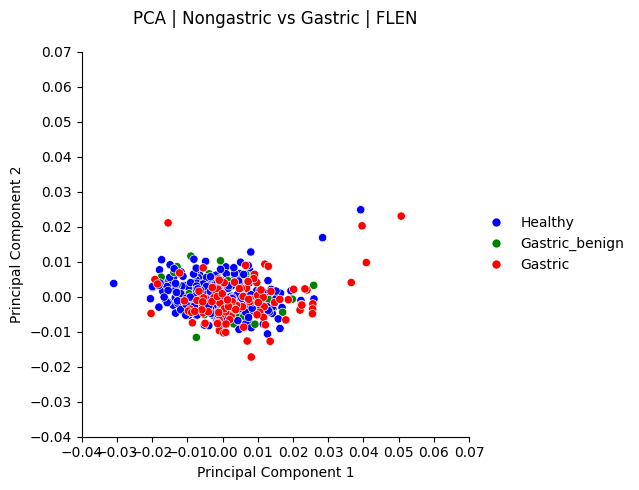

In [ ]:
f='FLEN'
healthy1=healthy[~healthy.iloc[:, 0].str.contains(special_sample, na=False)]
Nongastric1=pd.concat([healthy1,gastric_benign],axis=0)
PCAsigfea(
        DATA,
        SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
        stats_fea=stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        p='Nongastric vs Gastric',
        f=f,
        sig=False,alpha=0.05,
        show_ID=True,IDs=[special_sample],
        plot_pct_explain=False,top_pc=2,
        yticks=[-0.04,0.07,0.01],xticks=[-0.04,0.07,0.01],
        save=False,figname='PCA.png'
              )

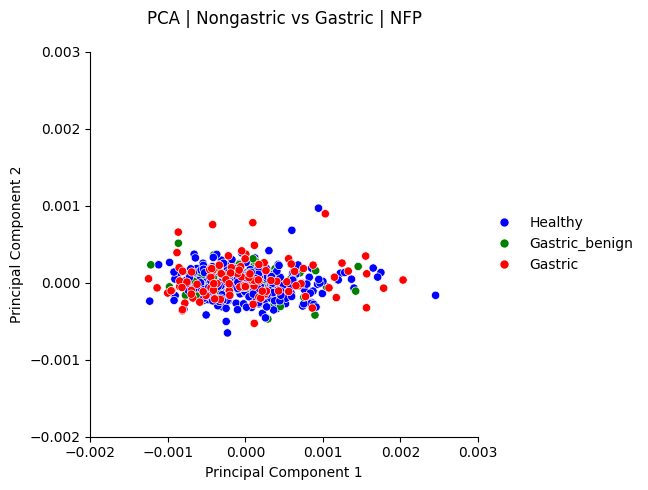

In [ ]:
f='NFP'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=[special_sample],
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.002,0.004,0.001],xticks=[-0.002,0.004,0.001],
      save=False,figname='PCA.png'
            )

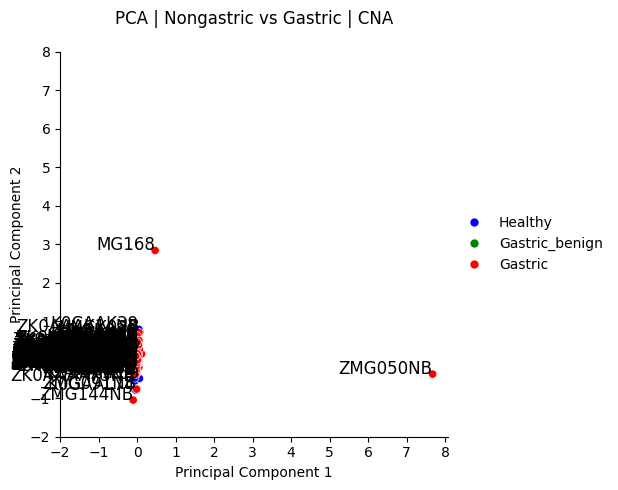

In [ ]:
f='CNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=list(set(sample_list_all['SampleID'])-set(special_sample)),
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

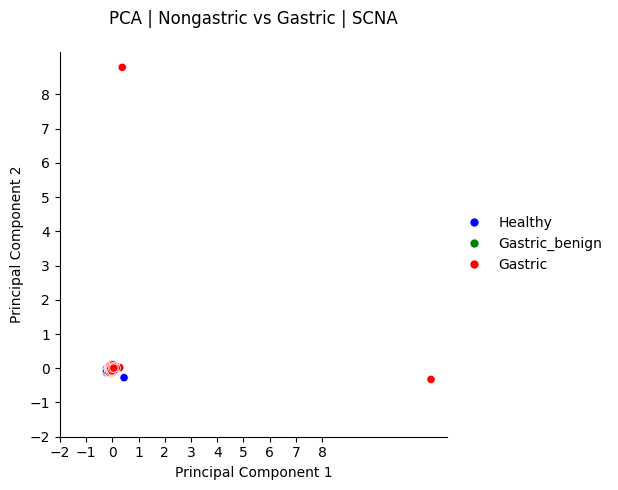

In [ ]:
f='SCNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=[special_sample],
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

t-SNE

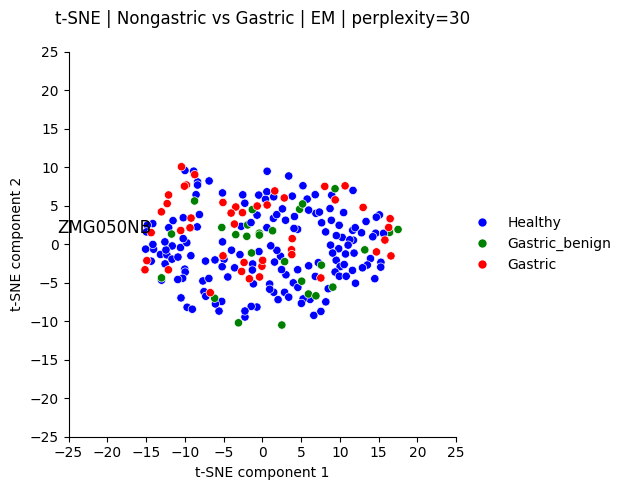

In [ ]:
f='EM'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-25,30,5],
    xticks=[-25,30,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

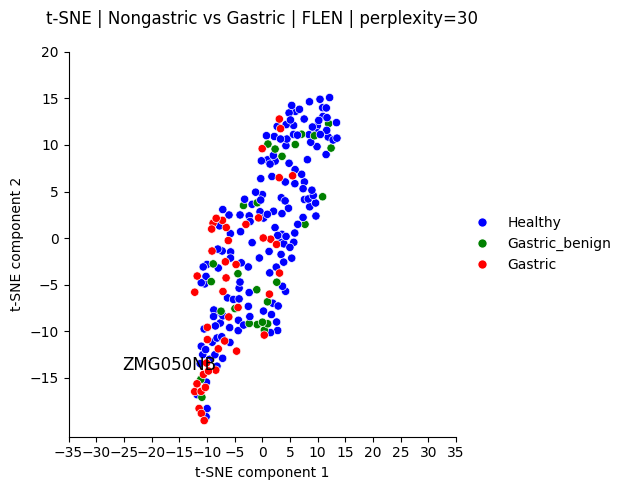

In [ ]:
f='FLEN'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-15,25,5],
    xticks=[-35,40,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

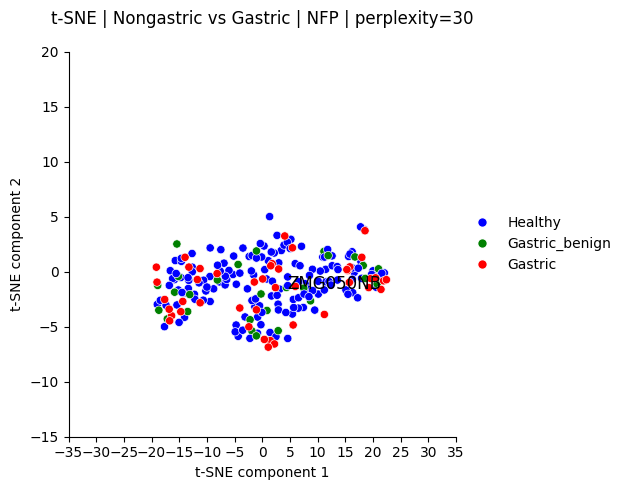

In [ ]:
f='NFP'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-15,25,5],
    xticks=[-35,40,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

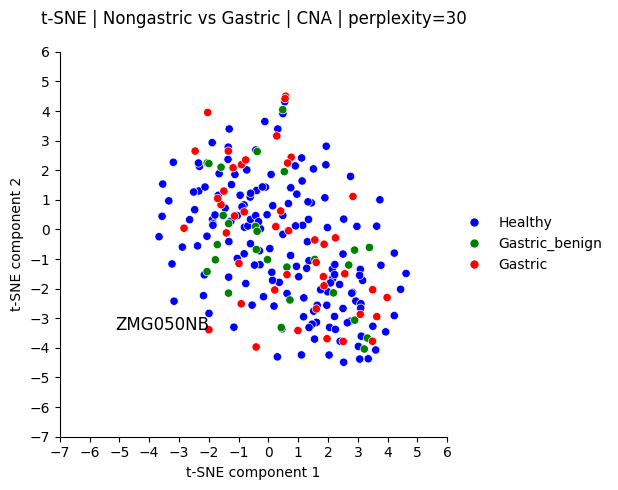

In [ ]:
f='CNA'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-7,7,1],
    xticks=[-7,7,1],
    perplexity=30,
    save=False,
    figname='TSNE.png')

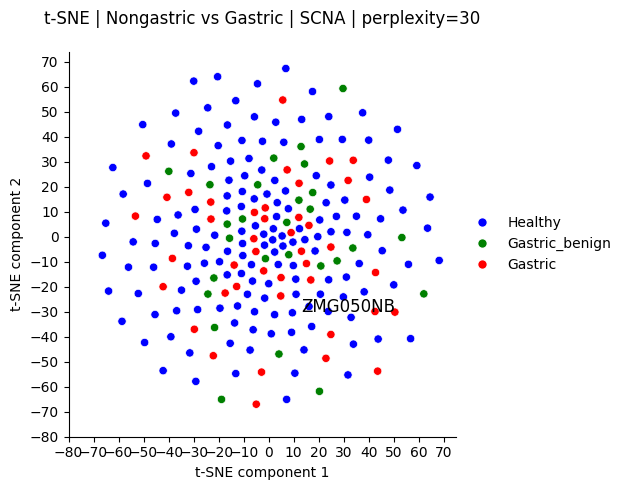

In [ ]:
f='SCNA'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-80,80,10],
    xticks=[-80,80,10],
    perplexity=30,
    save=False,
    figname='TSNE.png')

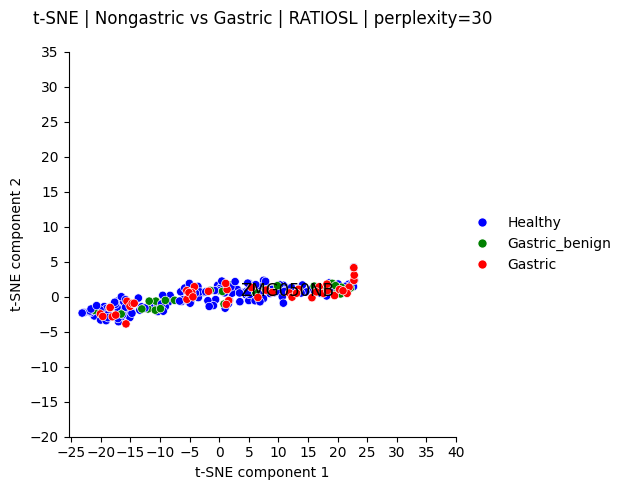

In [ ]:
f='RATIOSL'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-20,40,5],
    xticks=[-25,45,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

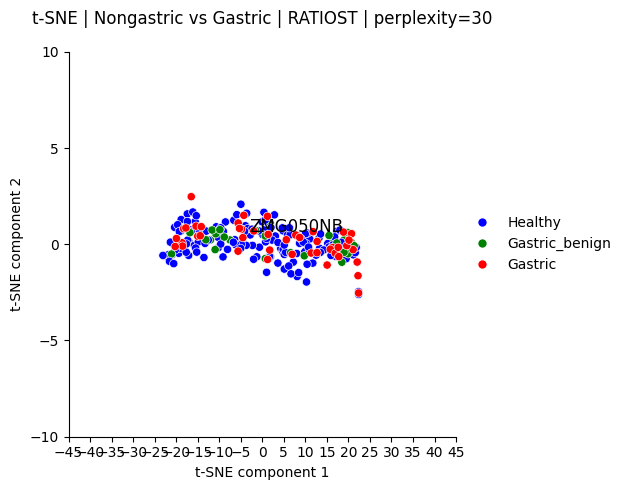

In [ ]:
f='RATIOST'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-10,15,5],
    xticks=[-45,50,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

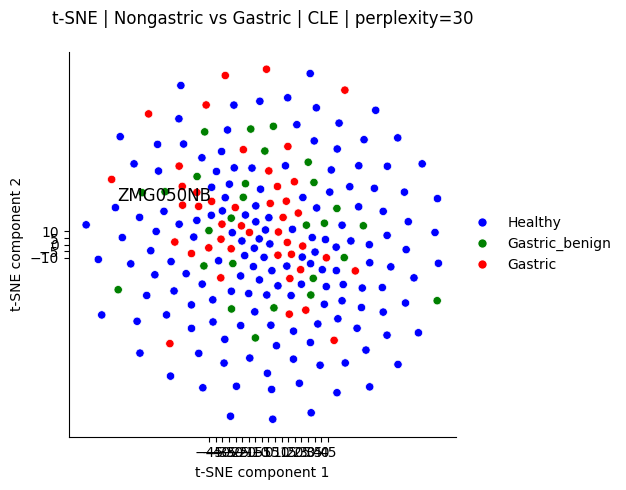

In [ ]:
f='CLE'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-10,15,5],
    xticks=[-45,50,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

UMAP

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


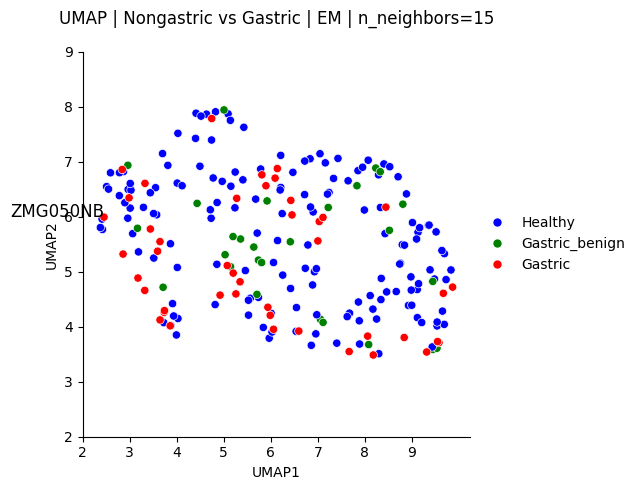

In [ ]:
f='EM'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[2,10,1],
        xticks=[2,10,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


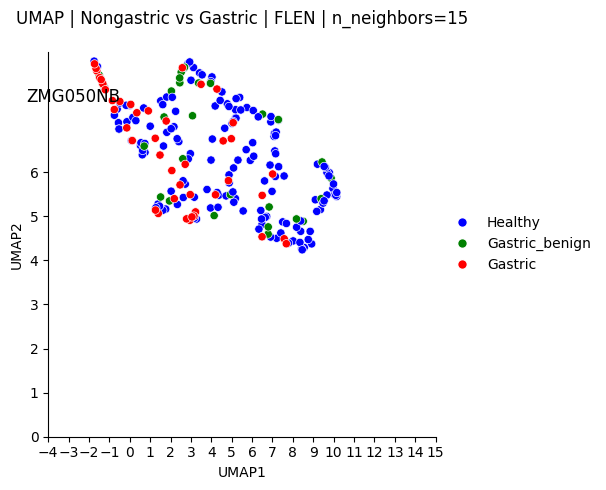

In [ ]:
f='FLEN'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[0,7,1],
        xticks=[-4,16,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


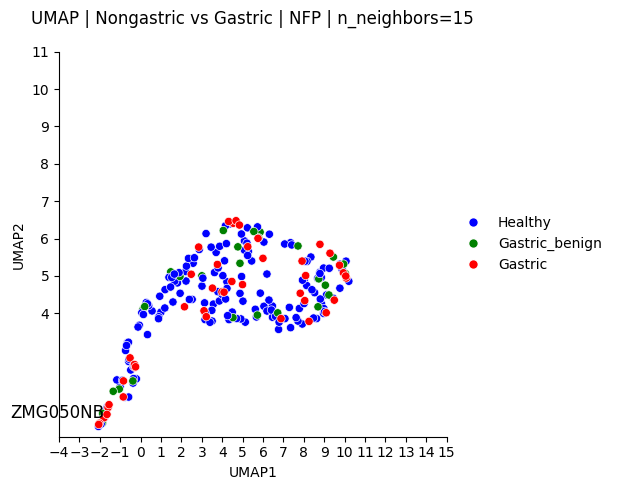

In [ ]:
f='NFP'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[4,12,1],
        xticks=[-4,16,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


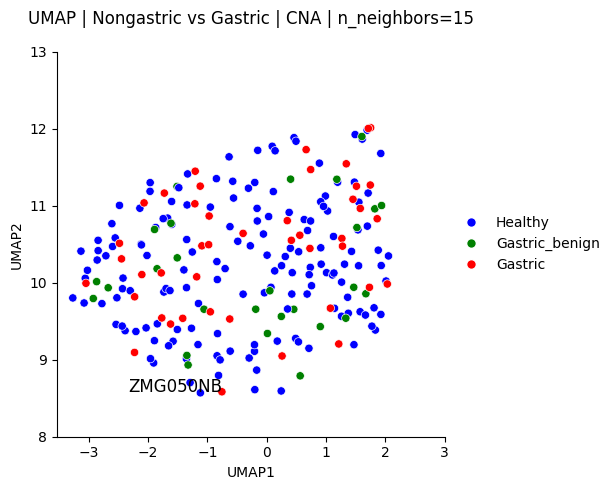

In [ ]:
f='CNA'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[8,14,1],
        xticks=[-3,4,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


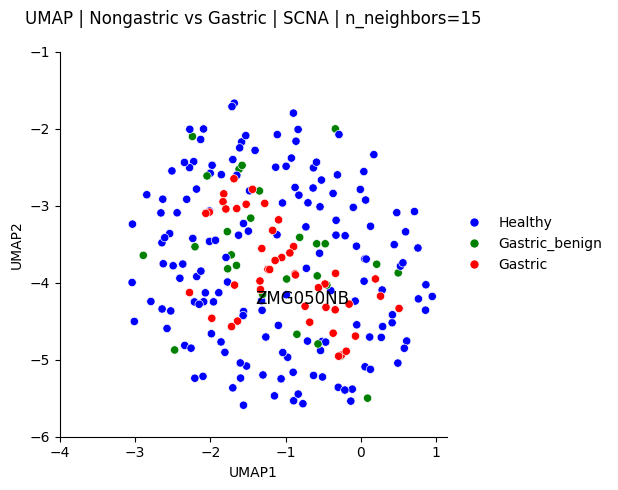

In [ ]:
f='SCNA'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[-6,0,1],
        xticks=[-4,2,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


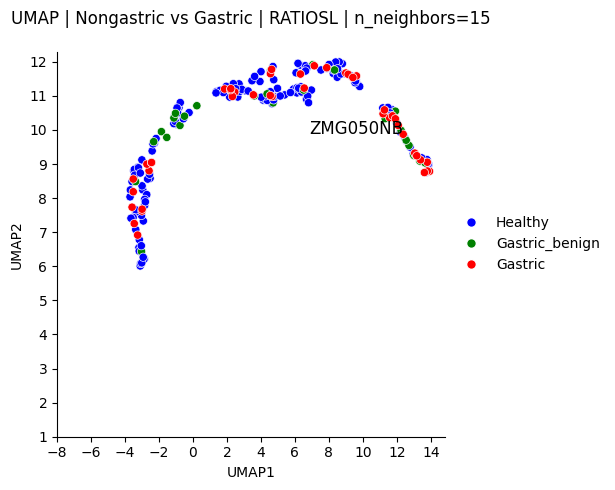

In [ ]:
f='RATIOSL'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[1,13,1],
        xticks=[-8,16,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


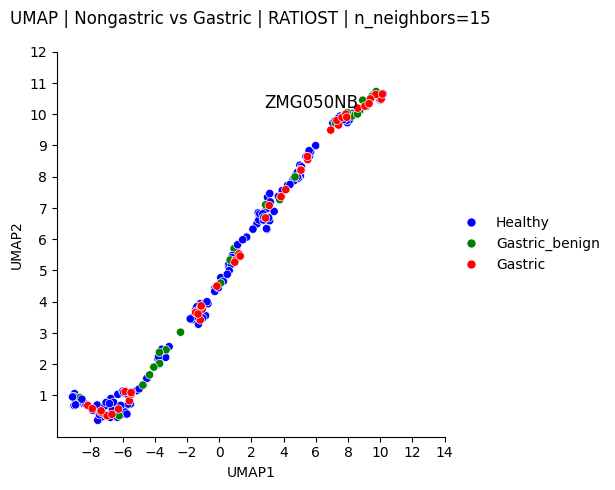

In [ ]:
f='RATIOST'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[1,13,1],
        xticks=[-8,16,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


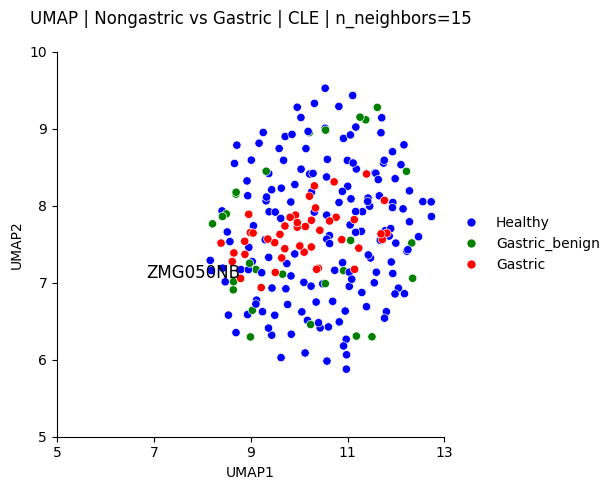

In [ ]:
f='CLE'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[5,11,1],
        xticks=[5,14,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

LDA

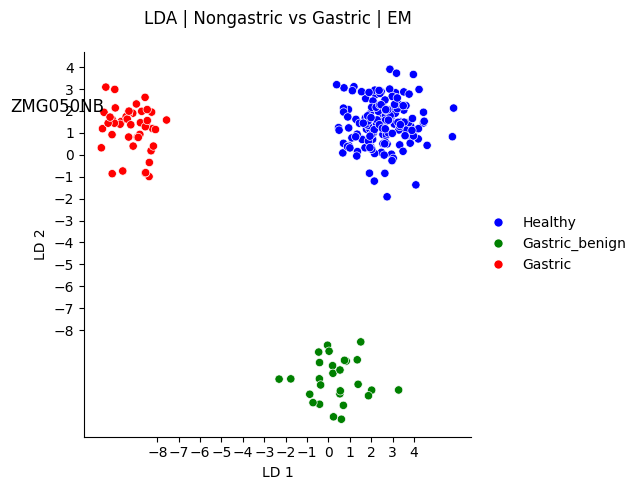

In [ ]:
f='EM'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

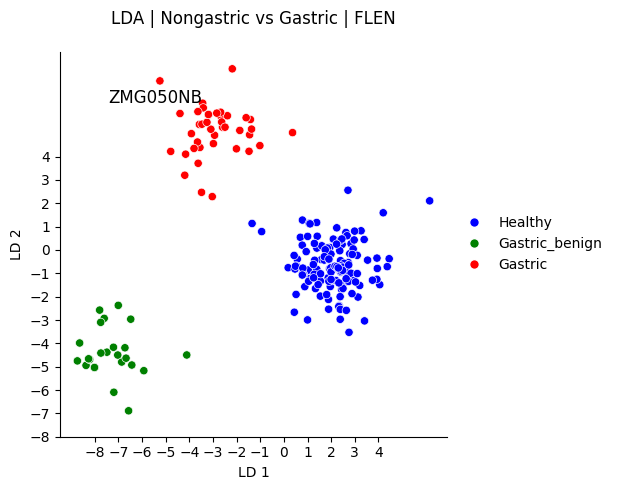

In [ ]:
f='FLEN'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

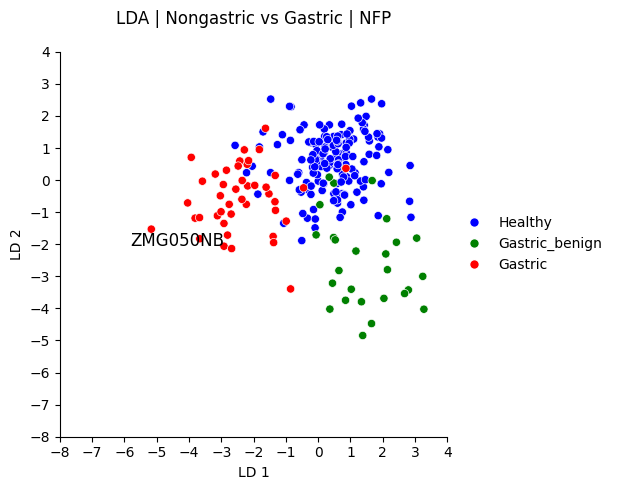

In [ ]:
f='NFP'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

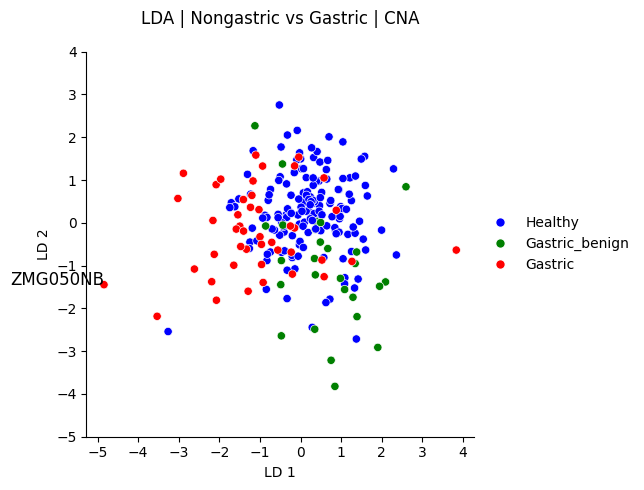

In [ ]:
f='CNA'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,5,1],
              save=False,figname='LDA.png'
              )

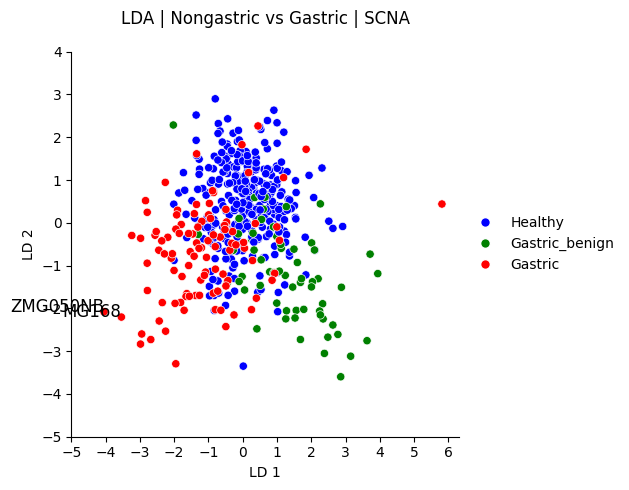

In [ ]:
f='SCNA'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False,figname='LDA.png'
              )

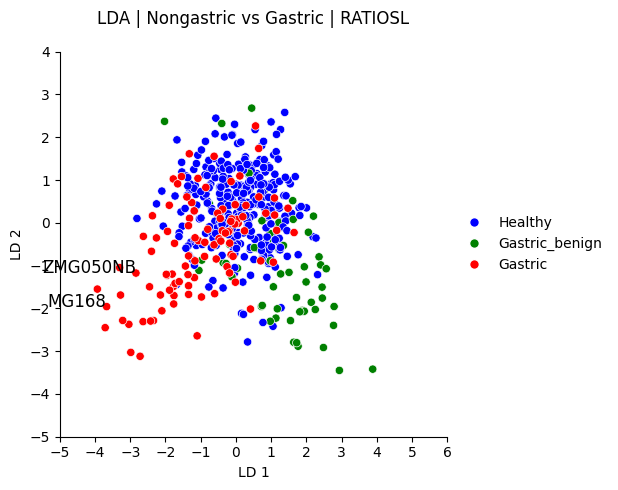

In [ ]:
f='RATIOSL'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False,figname='LDA.png'
              )

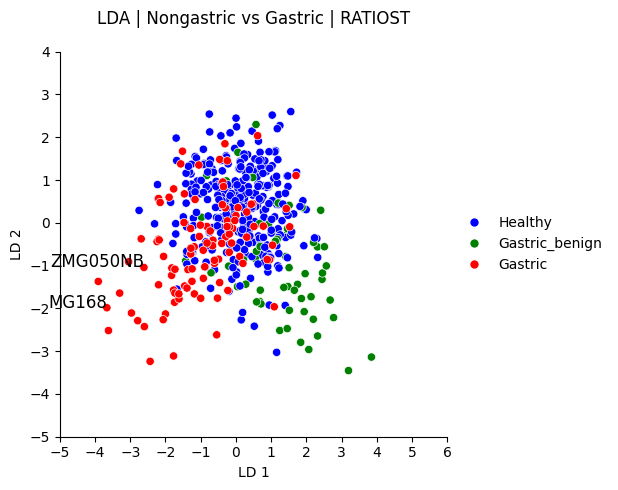

In [ ]:
f='RATIOST'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False)

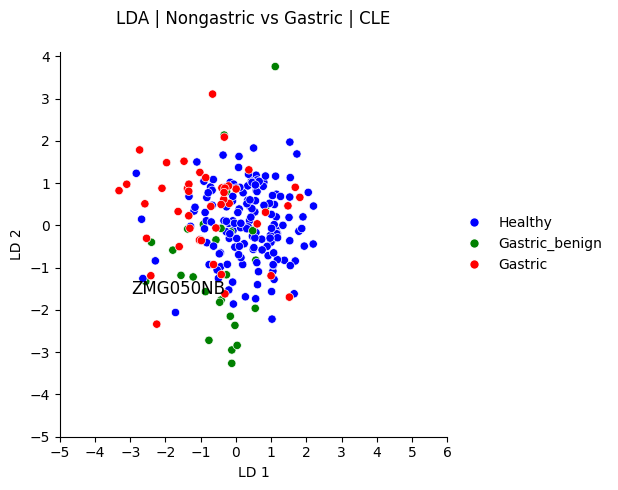

In [ ]:
f='CLE'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False)